# Comprehensive EDA — Startup Success Dataset (D8 Research Subset)

**Dataset:** `data/data.csv` — 20-variable research subset of the D8 startup dataset  
**Outcome:** `Dependent-Company Status` (Success / Failed)  
**n = 472 startups**, primarily US/tech, founded 2005–2013

Each section produces its own self-contained chart.

## 0 · Setup

In [39]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'Success': '#2ecc71', 'Failed': '#e74c3c'}
FIG_DPI  = 150

# ── Load ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('data/data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (472, 20)


,Dependent-Company Status,Number of Co-founders,B2C or B2B venture?,Time to 1st investment (in months),Number of of advisors,Team size Senior leadership,Employees count MoM change,Internet Activity Score,Last round of funding received (in milionUSD),Number of Investors in Angel and or VC,Number of of repeat investors,Presence of a top angel or venture fund in previous round of investment,Average Years of experience for founder and co founder,Have been part of successful startups in the past?,Degree from a Tier 1 or Tier 2 university?,Linear or Non-linear business model,"Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive",year of founding,Industry trend in investing,Disruptiveness of technology
0,Success,1,B2C,No Info,2,2,0.0,-1.0,0.45,0,4,Yes,High,No,Tier_1,Linear,Yes,No Info,2.0,Low
1,Success,2,B2C,10,0,4,NaN,125.0,5,0,0,No,High,Yes,Tier_1,Non-Linear,No,2011,3.0,Medium
2,Success,3,B2B,2,0,7,0.0,455.0,2.35,0,0,No,Medium,No,Tier_2,Non-Linear,No,2011,3.0,Medium


In [40]:
import subprocess, sys

# Install missing packages directly into the active kernel's environment
pkgs = ['matplotlib', 'seaborn']
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])

## 1 · Data Cleaning & Type Coercion

Before any visualisation we:
1. Replace the string `"No Info"` with `NaN` everywhere.
2. Force numeric columns to `float` (they were stored as strings).
3. Normalise free-text categoricals (strip whitespace, title-case).
4. Create a clean binary `success` flag (0/1) for arithmetic.

In [41]:
df = df_raw.copy()

# ── 1. Mask 'No Info' as NaN ──────────────────────────────────────────────────
df.replace('No Info', np.nan, inplace=True)

# ── 2. Force numeric coercion ─────────────────────────────────────────────────
NUMERIC_COLS = [
    'Number of Co-founders',
    'Time to 1st investment (in months)',
    'Number of of advisors',
    'Team size Senior leadership',
    'Employees count MoM change',
    'Internet Activity Score',
    'Last round of funding received (in milionUSD)',
    'Number of Investors in Angel and or VC',
    'Number of of repeat investors',
    'year of founding',
    'Industry trend in investing',
]
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 3. Normalise categoricals ─────────────────────────────────────────────────
CAT_COLS = [
    'Dependent-Company Status',
    'B2C or B2B venture?',
    'Presence of a top angel or venture fund in previous round of investment',
    'Average Years of experience for founder and co founder',
    'Have been part of successful startups in the past?',
    'Degree from a Tier 1 or Tier 2 university?',
    'Linear or Non-linear business model',
    'Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive',
    'Disruptiveness of technology',
]
for col in CAT_COLS:
    df[col] = df[col].astype(str).str.strip().replace('nan', np.nan)

# ── 4. Binary outcome helper ──────────────────────────────────────────────────
df['success'] = (df['Dependent-Company Status'] == 'Success').astype(int)

# ── Short column aliases (for plot labels) ────────────────────────────────────
SHORT = {
    'Number of Co-founders':                                  'Co-founders',
    'B2C or B2B venture?':                                    'B2B/B2C',
    'Time to 1st investment (in months)':                     'Time to 1st inv. (mo)',
    'Number of of advisors':                                  'Advisors',
    'Team size Senior leadership':                            'Senior leadership',
    'Employees count MoM change':                             'Employee MoM Δ (%)',
    'Internet Activity Score':                                'Internet Activity',
    'Last round of funding received (in milionUSD)':          'Last funding (M$)',
    'Number of Investors in Angel and or VC':                 'Angel/VC investors',
    'Number of of repeat investors':                          'Repeat investors',
    'Presence of a top angel or venture fund in previous round of investment': 'Top fund present',
    'Average Years of experience for founder and co founder': 'Founder exp.',
    'Have been part of successful startups in the past?':     'Prior success',
    'Degree from a Tier 1 or Tier 2 university?':            'Univ. tier',
    'Linear or Non-linear business model':                    'Business model',
    'Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive': 'Capital intensive',
    'year of founding':                                       'Year founded',
    'Industry trend in investing':                            'Inv. trend (0-5)',
    'Disruptiveness of technology':                           'Tech disruptiveness',
}

print('Cleaned shape:', df.shape)
print('Success rate: {:.1%}'.format(df['success'].mean()))

Cleaned shape: (472, 21)
Success rate: 64.6%


## 1.5 · Econometrics-Ready Dataset

Before any analysis, build a modelling dataset called `econ_df`.

This version of the data is designed for econometrics work:
- binary categoricals become explicit `0/1` dummies
- ordered categoricals become numeric scores
- `Last funding (M$)`, `Employee MoM Delta (%)`, and all university-tier variables are removed from the analysis set
- remaining missing values are filled with targeted imputation based on related startup characteristics
- the final `econ_df` used below is fully numeric and ready for regression-style analysis

In [42]:
# Econometrics-ready numeric dataset used throughout the notebook

econ_df = df.copy()

binary_dummy_specs = {
    'Dependent-Company Status': ('success', {'Success': 1, 'Failed': 0}),
    'Presence of a top angel or venture fund in previous round of investment': ('d_top_fund', {'Yes': 1, 'No': 0}),
    'Have been part of successful startups in the past?': ('d_prior_success', {'Yes': 1, 'No': 0}),
    'Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive': ('d_capital_intensive', {'Yes': 1, 'No': 0}),
    'B2C or B2B venture?': ('d_b2b', {'B2B': 1, 'B2C': 0}),
    'Linear or Non-linear business model': ('d_nonlinear', {'Non-Linear': 1, 'Linear': 0}),
}

for source_col, (dummy_col, mapping) in binary_dummy_specs.items():
    econ_df[dummy_col] = econ_df[source_col].map(mapping).astype('Int64')

ordinal_specs = {
    'Average Years of experience for founder and co founder': ('founder_experience_score', {'Low': 1, 'Medium': 2, 'High': 3}),
    'Disruptiveness of technology': ('tech_disruptiveness_score', {'Low': 1, 'Medium': 2, 'High': 3}),
}

for source_col, (score_col, mapping) in ordinal_specs.items():
    econ_df[score_col] = econ_df[source_col].map(mapping).astype('Int64')

raw_columns_to_drop = [
    'Dependent-Company Status',
    'Presence of a top angel or venture fund in previous round of investment',
    'Have been part of successful startups in the past?',
    'Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive',
    'B2C or B2B venture?',
    'Linear or Non-linear business model',
    'Average Years of experience for founder and co founder',
    'Degree from a Tier 1 or Tier 2 university?',
    'Disruptiveness of technology',
    'Last round of funding received (in milionUSD)',
    'Employees count MoM change',
]

econ_df = econ_df.drop(columns=raw_columns_to_drop)

FEATURE_LABELS = {
    'success': 'Success',
    'Number of Co-founders': 'Co-founders',
    'Time to 1st investment (in months)': 'Time to 1st inv. (mo)',
    'Number of of advisors': 'Advisors',
    'Team size Senior leadership': 'Senior leadership',
    'Internet Activity Score': 'Internet activity',
    'Number of Investors in Angel and or VC': 'Angel/VC investors',
    'Number of of repeat investors': 'Repeat investors',
    'year of founding': 'Founding year',
    'Industry trend in investing': 'Industry trend',
    'd_top_fund': 'Top fund',
    'd_prior_success': 'Prior success',
    'd_capital_intensive': 'Capital intensive',
    'd_b2b': 'B2B',
    'd_nonlinear': 'Non-linear model',
    'founder_experience_score': 'Founder exp. score',
    'tech_disruptiveness_score': 'Tech disruptiveness',
}
SHORT.update(FEATURE_LABELS)

ANALYSIS_FEATURES = [
    'Number of Co-founders',
    'Time to 1st investment (in months)',
    'Number of of advisors',
    'Team size Senior leadership',
    'Internet Activity Score',
    'Number of Investors in Angel and or VC',
    'Number of of repeat investors',
    'year of founding',
    'Industry trend in investing',
    'd_top_fund',
    'd_prior_success',
    'd_capital_intensive',
    'd_b2b',
    'd_nonlinear',
    'founder_experience_score',
    'tech_disruptiveness_score',
]

CONTINUOUS_FEATURES = [
    'Number of Co-founders',
    'Time to 1st investment (in months)',
    'Number of of advisors',
    'Team size Senior leadership',
    'Internet Activity Score',
    'Number of Investors in Angel and or VC',
    'Number of of repeat investors',
    'year of founding',
    'Industry trend in investing',
]
BINARY_FEATURES = ['d_top_fund', 'd_prior_success', 'd_capital_intensive', 'd_b2b', 'd_nonlinear']
ORDINAL_FEATURES = ['founder_experience_score', 'tech_disruptiveness_score']

missing_before_imputation = econ_df[ANALYSIS_FEATURES].isna().sum().copy()


def first_mode(series):
    non_null = series.dropna()
    if non_null.empty:
        return np.nan
    return non_null.mode().iloc[0]


def targeted_fill(frame, column, group_sets, strategy='median', round_result=False, cast_to_int=False):
    filled = frame[column].copy()
    before = int(filled.isna().sum())
    if before == 0:
        if cast_to_int:
            filled = filled.astype('Int64')
        return filled, before, before

    working = frame.copy()
    working[column] = filled

    for group_cols in group_sets:
        if strategy == 'median':
            stat = working.groupby(group_cols)[column].transform('median')
        else:
            stat = working.groupby(group_cols)[column].transform(first_mode)
        filled = filled.fillna(stat)
        working[column] = filled

    if strategy == 'median':
        fallback = filled.median()
    else:
        fallback_mode = filled.dropna().mode()
        fallback = fallback_mode.iloc[0] if not fallback_mode.empty else np.nan

    filled = filled.fillna(fallback)
    if round_result:
        filled = filled.round()
    if cast_to_int:
        filled = filled.astype('Int64')

    after = int(filled.isna().sum())
    return filled, before, after


imputation_plan = [
    ('d_b2b', [['d_nonlinear'], ['d_capital_intensive']], 'mode', True, True),
    ('d_nonlinear', [['d_b2b'], ['d_capital_intensive']], 'mode', True, True),
    ('d_capital_intensive', [['d_b2b', 'd_nonlinear'], ['d_b2b']], 'mode', True, True),
    ('d_top_fund', [['d_b2b', 'd_prior_success'], ['d_b2b']], 'mode', True, True),
    ('d_prior_success', [['d_top_fund', 'd_b2b'], ['d_top_fund']], 'mode', True, True),
    ('year of founding', [['d_b2b', 'd_nonlinear'], ['d_b2b']], 'median', True, True),
    ('Industry trend in investing', [['year of founding', 'd_b2b'], ['year of founding']], 'median', True, True),
    ('founder_experience_score', [['d_prior_success', 'd_top_fund'], ['d_prior_success']], 'median', True, True),
    ('tech_disruptiveness_score', [['d_nonlinear', 'd_capital_intensive'], ['d_nonlinear']], 'median', True, True),
    ('Time to 1st investment (in months)', [['d_top_fund', 'd_prior_success', 'd_b2b'], ['d_top_fund', 'd_b2b'], ['d_b2b']], 'median', True, True),
    ('Internet Activity Score', [['d_b2b', 'year of founding'], ['d_b2b']], 'median', False, False),
    ('Number of Investors in Angel and or VC', [['d_top_fund', 'd_prior_success'], ['d_top_fund']], 'median', True, True),
    ('Number of of repeat investors', [['d_top_fund', 'd_prior_success'], ['d_top_fund']], 'median', True, True),
]

imputation_log = []
for column, group_sets, strategy, round_result, cast_to_int in imputation_plan:
    econ_df[column], missing_before, missing_after = targeted_fill(
        econ_df, column, group_sets, strategy=strategy,
        round_result=round_result, cast_to_int=cast_to_int,
    )
    imputation_log.append({
        'feature': column,
        'strategy': strategy,
        'missing_before': missing_before,
        'missing_after': missing_after,
    })

imputation_summary = pd.DataFrame(imputation_log)
missing_after_imputation = econ_df[ANALYSIS_FEATURES].isna().sum().copy()

status_map = {1: 'Success', 0: 'Failed'}
outcome_palette = {1: PALETTE['Success'], 0: PALETTE['Failed']}

non_numeric_cols = econ_df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Econometrics-ready shape: {econ_df.shape}')
print(f'Remaining non-numeric columns: {non_numeric_cols if non_numeric_cols else "None"}')
print(f'Missing cells in analysis features after imputation: {int(missing_after_imputation.sum())}')
print('\nPreview of numeric modelling frame:')
display(econ_df[['success'] + ANALYSIS_FEATURES].head())
print('\nTargeted imputation summary:')
display(imputation_summary)

df_econ = econ_df.copy()

Econometrics-ready shape: (472, 17)
Remaining non-numeric columns: None
Missing cells in analysis features after imputation: 0

Preview of numeric modelling frame:


,success,Number of Co-founders,Time to 1st investment (in months),Number of of advisors,Team size Senior leadership,Internet Activity Score,Number of Investors in Angel and or VC,Number of of repeat investors,year of founding,Industry trend in investing,d_top_fund,d_prior_success,d_capital_intensive,d_b2b,d_nonlinear,founder_experience_score,tech_disruptiveness_score
0,1,1,10,2,2,-1.0,0,4,2010,2,1,0,1,0,0,3,1
1,1,2,10,0,4,125.0,0,0,2011,3,0,1,0,0,1,3,2
2,1,3,2,0,7,455.0,0,0,2011,3,0,0,0,1,1,2,2
3,1,2,1,0,4,-99.0,0,0,2009,4,1,1,0,0,1,2,2
4,1,1,13,1,8,496.0,0,0,2010,3,0,0,1,1,1,3,2



Targeted imputation summary:


,feature,strategy,missing_before,missing_after
0,d_b2b,mode,3,0
1,d_nonlinear,mode,18,0
2,d_capital_intensive,mode,26,0
3,d_top_fund,mode,97,0
4,d_prior_success,mode,20,0
5,year of founding,median,59,0
6,Industry trend in investing,median,82,0
7,founder_experience_score,median,80,0
8,tech_disruptiveness_score,median,82,0
9,Time to 1st investment (in months),median,96,0


## 2 · `econ_df` Overview

Quick audit of the econometrics-ready dataset after encoding, variable removal, and targeted imputation.

In [43]:
audit = pd.DataFrame({
    'dtype': econ_df[ANALYSIS_FEATURES + ['success']].dtypes.astype(str),
    'missing_before': missing_before_imputation.reindex(ANALYSIS_FEATURES + ['success']).fillna(0).astype(int),
    'missing_after': econ_df[ANALYSIS_FEATURES + ['success']].isna().sum(),
    'mean': econ_df[ANALYSIS_FEATURES + ['success']].mean().round(3),
    'std': econ_df[ANALYSIS_FEATURES + ['success']].std().round(3),
})

audit.index = [SHORT.get(col, col) for col in audit.index]
display(audit)

print('Removed from analysis: Last funding, Employee MoM change, and university tier.')

,dtype,missing_before,missing_after,mean,std
Co-founders,int64,0,0,1.869,1.143
Time to 1st inv. (mo),Int64,96,0,12.979,17.171
Advisors,int64,0,0,1.017,2.015
Senior leadership,int64,0,0,3.731,2.517
Internet activity,float64,65,0,104.843,211.63
Angel/VC investors,Int64,49,0,0.517,1.334
Repeat investors,Int64,40,0,0.555,1.186
Founding year,Int64,59,0,2009.422,2.446
Industry trend,Int64,82,0,2.892,0.784
Top fund,Int64,97,0,0.197,0.398


Removed from analysis: Last funding, Employee MoM change, and university tier.


## 3 · Missingness Before vs After Imputation

A direct check that the remaining missing values in the analysis set were handled by the targeted imputation step.

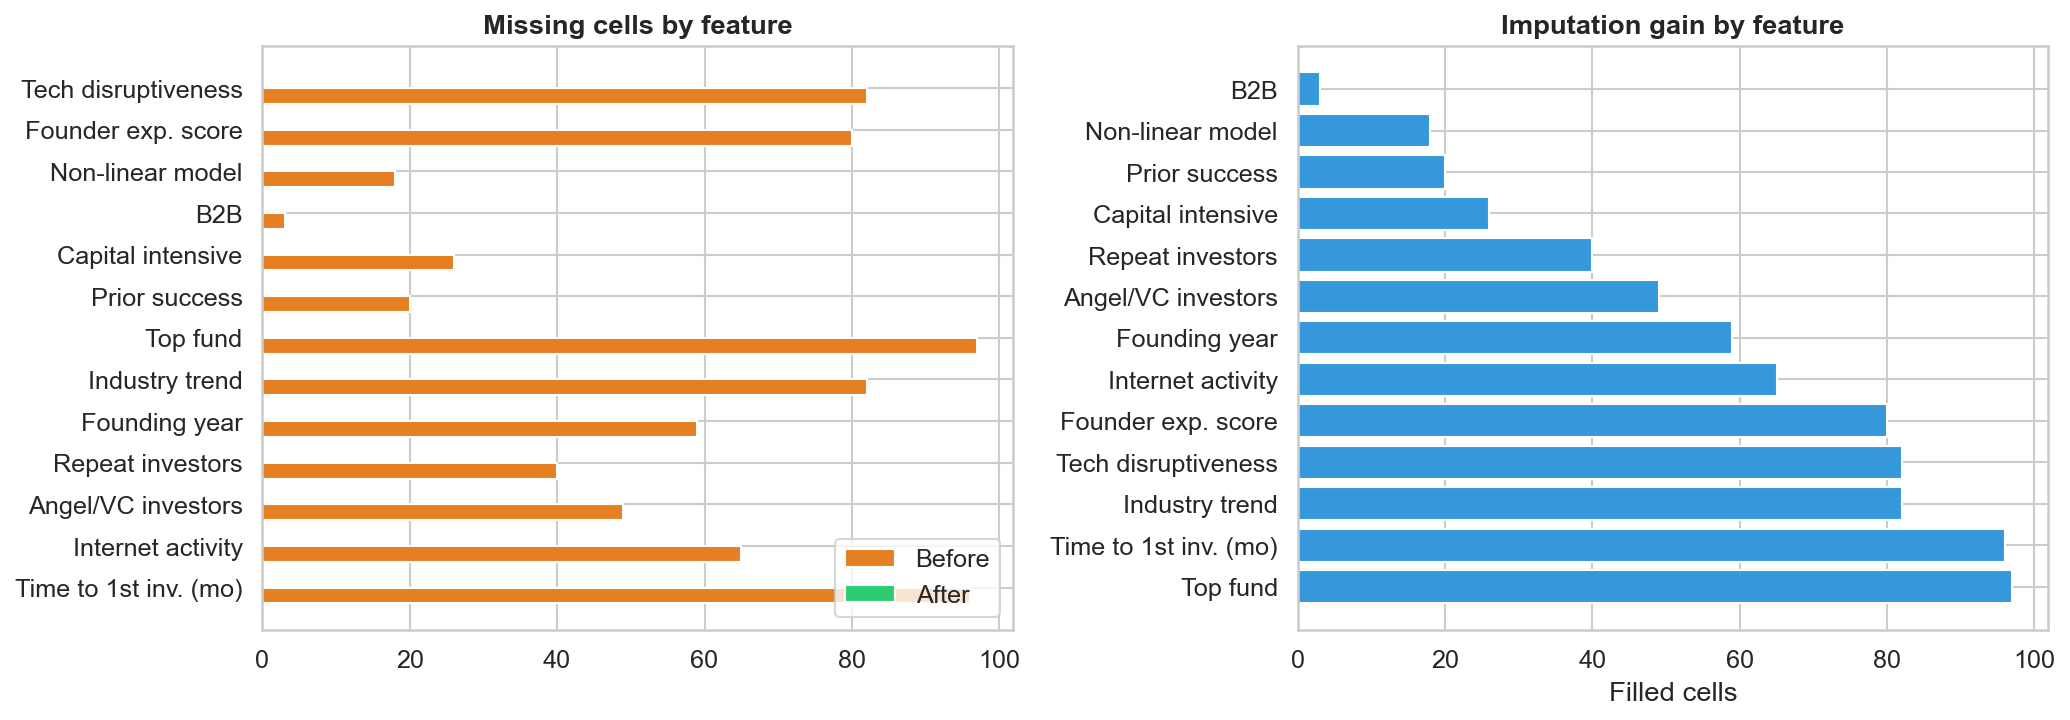

,feature,strategy,missing_before,missing_after
0,d_b2b,mode,3,0
1,d_nonlinear,mode,18,0
2,d_capital_intensive,mode,26,0
3,d_top_fund,mode,97,0
4,d_prior_success,mode,20,0
5,year of founding,median,59,0
6,Industry trend in investing,median,82,0
7,founder_experience_score,median,80,0
8,tech_disruptiveness_score,median,82,0
9,Time to 1st investment (in months),median,96,0


In [44]:
missing_compare = pd.DataFrame({
    'before': missing_before_imputation.reindex(ANALYSIS_FEATURES).fillna(0).astype(int),
    'after': missing_after_imputation.reindex(ANALYSIS_FEATURES).fillna(0).astype(int),
})
missing_compare = missing_compare.loc[(missing_compare['before'] > 0) | (missing_compare['after'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

if missing_compare.empty:
    axes[0].text(0.5, 0.5, 'No missing values remained\nafter targeted imputation.',
                 ha='center', va='center', fontsize=12)
    axes[0].axis('off')
    axes[1].axis('off')
else:
    labels = [SHORT.get(c, c) for c in missing_compare.index]
    x = np.arange(len(labels))
    width = 0.38

    axes[0].barh(x - width/2, missing_compare['before'], height=width,
                 color='#e67e22', edgecolor='white', label='Before')
    axes[0].barh(x + width/2, missing_compare['after'], height=width,
                 color='#2ecc71', edgecolor='white', label='After')
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(labels)
    axes[0].set_title('Missing cells by feature', fontweight='bold')
    axes[0].legend()

    reduction = (missing_compare['before'] - missing_compare['after']).sort_values(ascending=False)
    axes[1].barh([SHORT.get(c, c) for c in reduction.index], reduction.values,
                 color='#3498db', edgecolor='white')
    axes[1].set_title('Imputation gain by feature', fontweight='bold')
    axes[1].set_xlabel('Filled cells')

plt.tight_layout()
plt.show()

display(imputation_summary[imputation_summary['missing_before'] > 0])

## 4 · Target Variable Distribution

The dependent variable in `econ_df` is the numeric dummy `success` where `1=Success` and `0=Failed`.

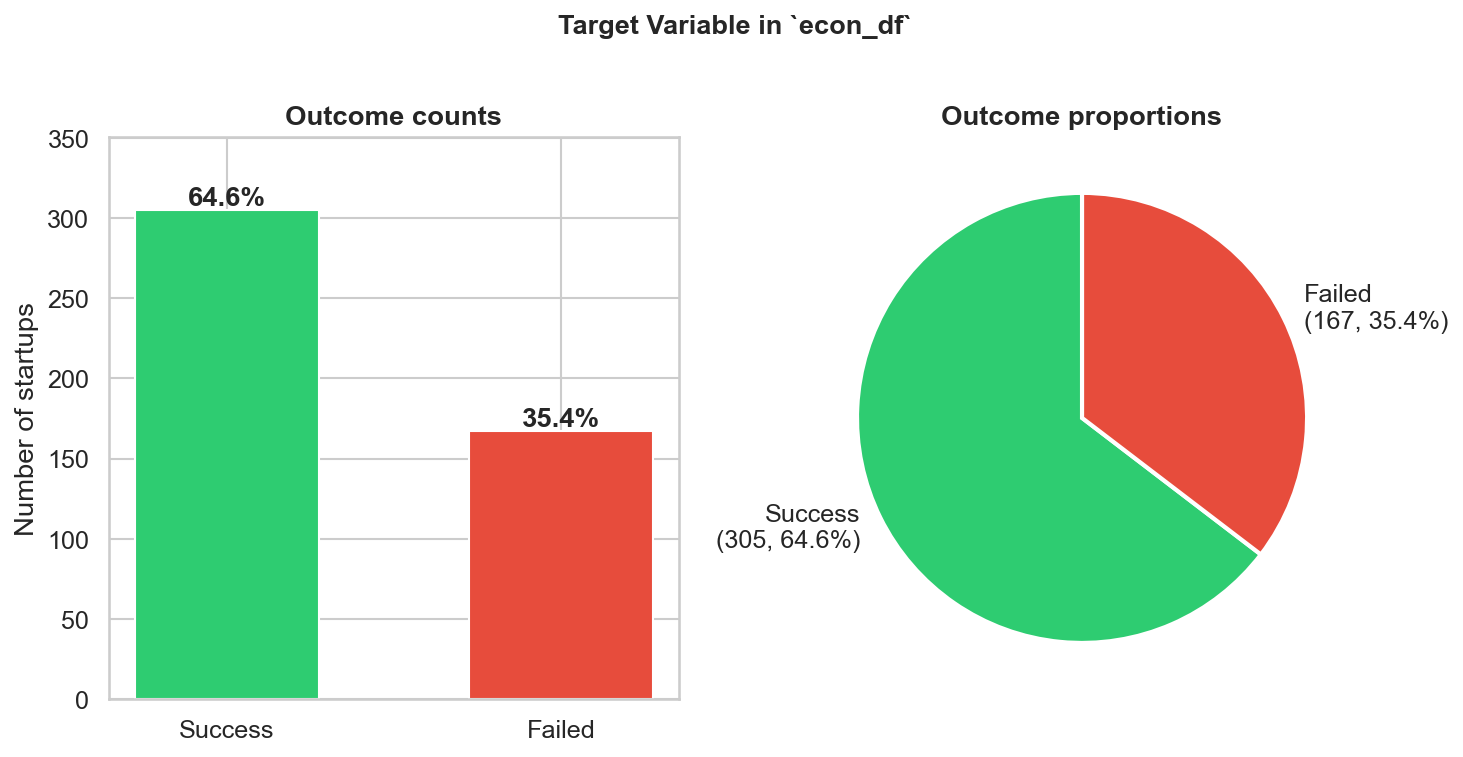

In [45]:
counts = econ_df['success'].map(status_map).value_counts().reindex(['Success', 'Failed'])
pcts = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=FIG_DPI)

bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[k] for k in counts.index], edgecolor='white', width=0.55)
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{pct:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Outcome counts', fontweight='bold')
axes[0].set_ylabel('Number of startups')
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values,
            labels=[f'{k}\n({v}, {p:.1f}%)' for k, v, p in zip(counts.index, counts.values, pcts.values)],
            colors=[PALETTE[k] for k in counts.index],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Outcome proportions', fontweight='bold')

plt.suptitle('Target Variable in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5 · Feature Distributions in `econ_df`

Histograms for the continuous and ordered predictors in the econometrics-ready dataset, split by the binary outcome.

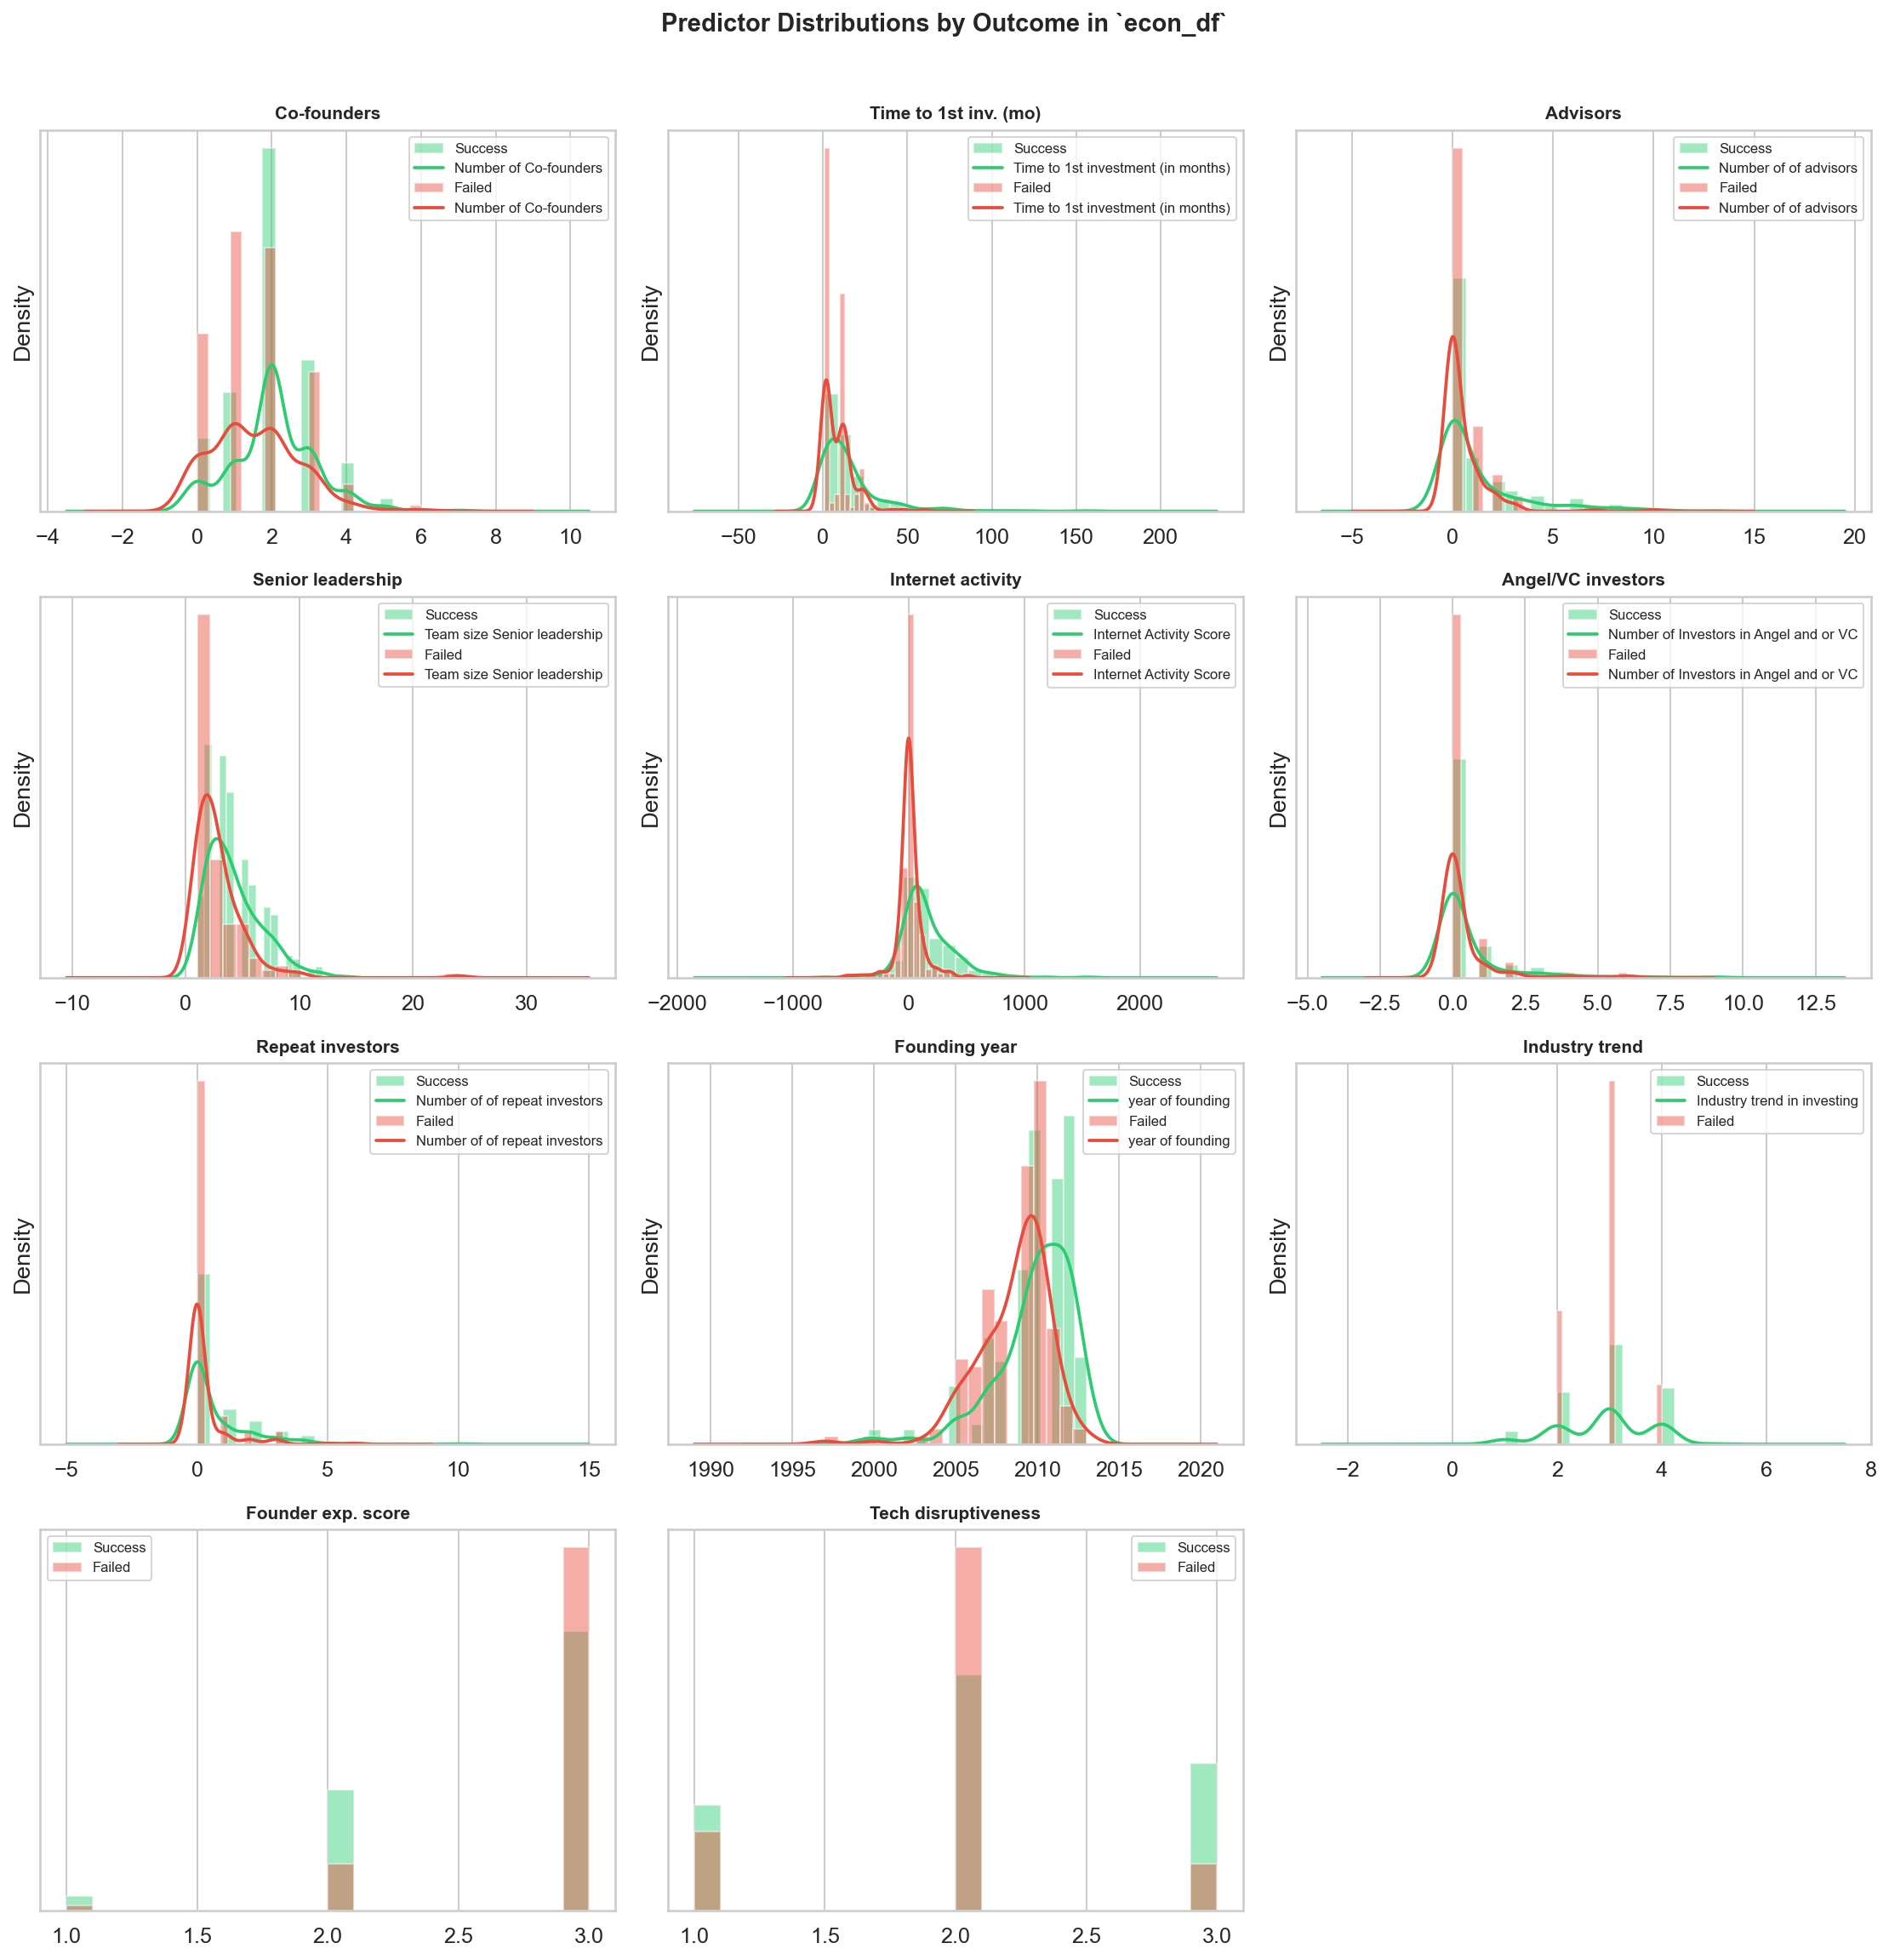

In [46]:
NUM_FEATURES = CONTINUOUS_FEATURES + ORDINAL_FEATURES

ncols = 3
nrows = -(-len(NUM_FEATURES) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.8), dpi=FIG_DPI)
axes = axes.flatten()

for ax, col in zip(axes, NUM_FEATURES):
    for status in [1, 0]:
        data = econ_df.loc[econ_df['success'] == status, col].dropna()
        ax.hist(data, bins=20, alpha=0.45, color=outcome_palette[status],
                density=True, label=status_map[status])
        if data.nunique() > 5:
            data.plot.kde(ax=ax, color=outcome_palette[status], linewidth=1.8)
    ax.set_title(SHORT.get(col, col), fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.set_yticks([])

for ax in axes[len(NUM_FEATURES):]:
    ax.set_visible(False)

plt.suptitle('Predictor Distributions by Outcome in `econ_df`', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6 · Binary Predictor Lift

For the dummy regressors, compare the success rate when the indicator equals `1` versus when it equals `0`.

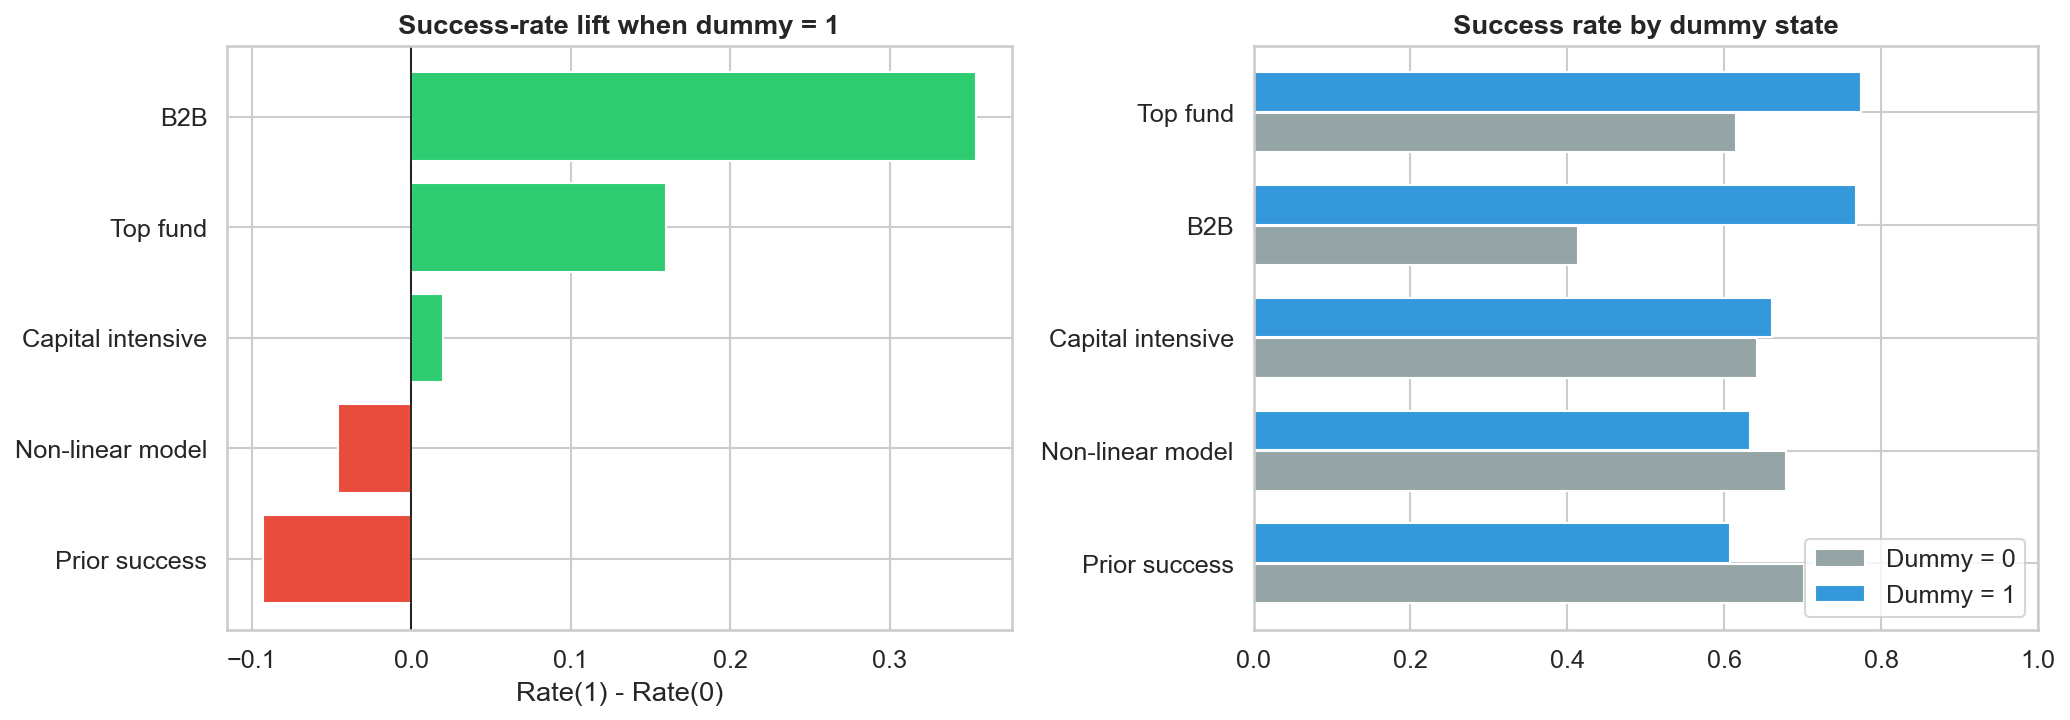

,feature,rate_if_0,rate_if_1,lift,n_if_0,n_if_1
1,d_prior_success,0.701031,0.607914,-0.093117,194,278
4,d_nonlinear,0.679104,0.633136,-0.045968,134,338
2,d_capital_intensive,0.641243,0.661017,0.019774,354,118
0,d_top_fund,0.614776,0.774194,0.159418,379,93
3,d_b2b,0.413580,0.767742,0.354162,162,310


In [47]:
binary_lift = []
for col in BINARY_FEATURES:
    grp = econ_df.groupby(col)['success'].agg(['mean', 'count'])
    rate_0 = grp.loc[0, 'mean'] if 0 in grp.index else np.nan
    rate_1 = grp.loc[1, 'mean'] if 1 in grp.index else np.nan
    n_0 = int(grp.loc[0, 'count']) if 0 in grp.index else 0
    n_1 = int(grp.loc[1, 'count']) if 1 in grp.index else 0
    binary_lift.append({
        'feature': col,
        'rate_if_0': rate_0,
        'rate_if_1': rate_1,
        'lift': rate_1 - rate_0,
        'n_if_0': n_0,
        'n_if_1': n_1,
    })

binary_lift = pd.DataFrame(binary_lift).sort_values('lift')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

axes[0].barh([SHORT.get(c, c) for c in binary_lift['feature']], binary_lift['lift'],
             color=['#2ecc71' if v > 0 else '#e74c3c' for v in binary_lift['lift']],
             edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Success-rate lift when dummy = 1', fontweight='bold')
axes[0].set_xlabel('Rate(1) - Rate(0)')

plot_df = binary_lift.sort_values('rate_if_1', ascending=True)
y = np.arange(len(plot_df))
axes[1].barh(y - 0.18, plot_df['rate_if_0'], height=0.35, color='#95a5a6', label='Dummy = 0')
axes[1].barh(y + 0.18, plot_df['rate_if_1'], height=0.35, color='#3498db', label='Dummy = 1')
axes[1].set_yticks(y)
axes[1].set_yticklabels([SHORT.get(c, c) for c in plot_df['feature']])
axes[1].set_title('Success rate by dummy state', fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

display(binary_lift)

## 9 · Outcome Separation by Feature

Standardized mean differences show which predictors separate successful and failed startups most strongly in the numeric `econ_df` design matrix.

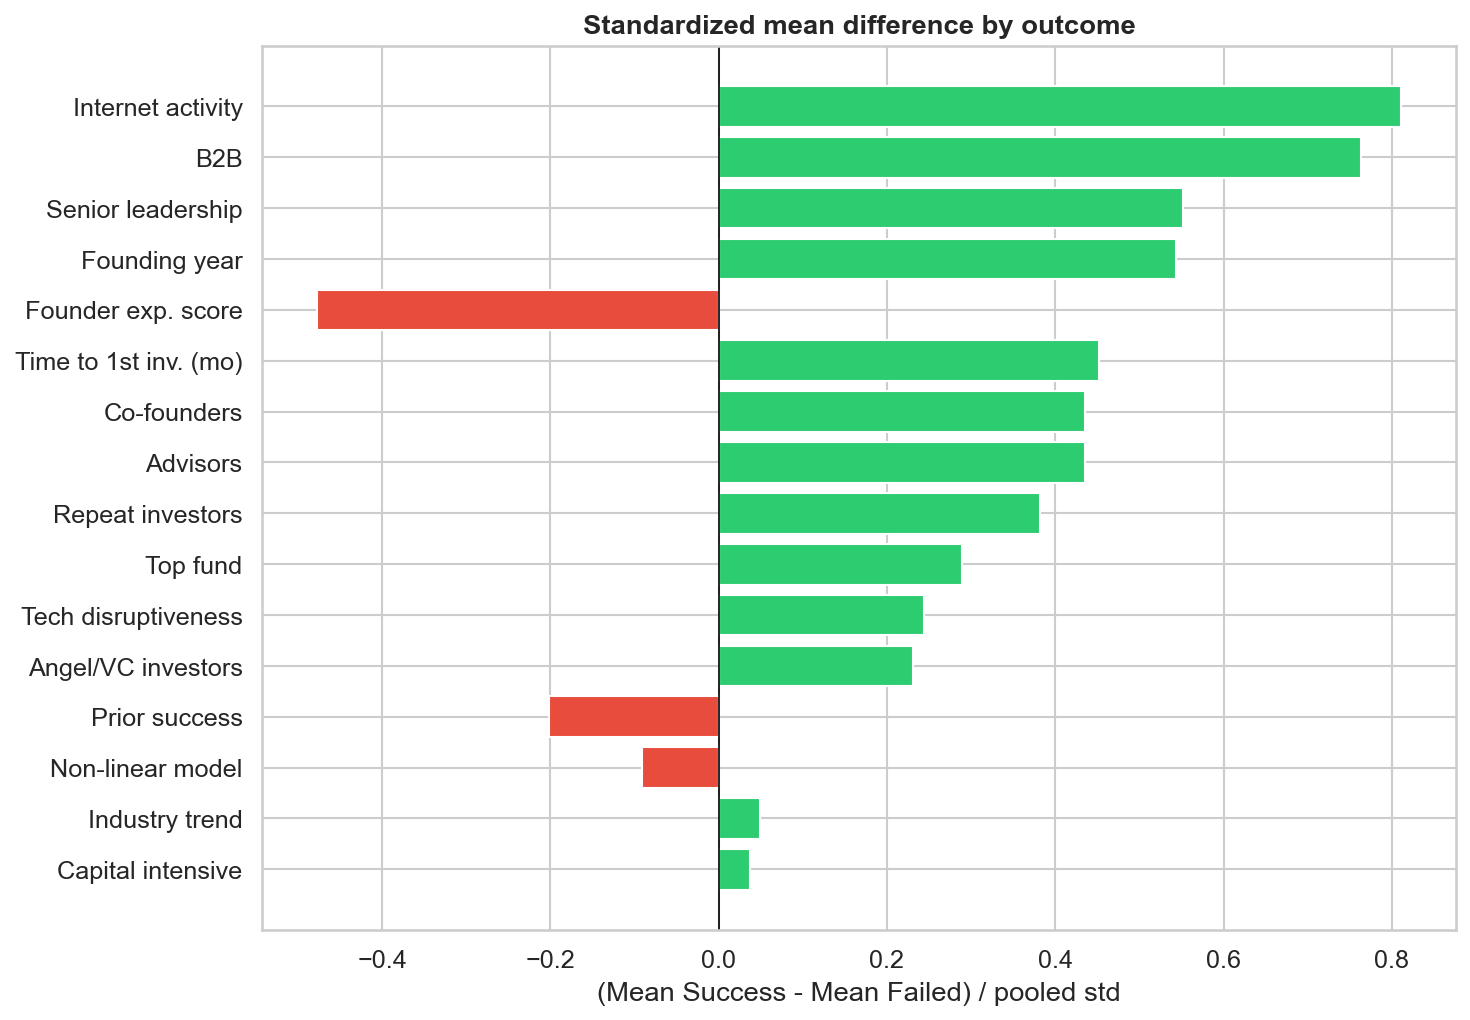

,feature,smd,success_mean,failed_mean
4,Internet Activity Score,0.811327,157.488525,8.694611
12,d_b2b,0.763163,0.780328,0.431138
3,Team size Senior leadership,0.551248,4.206557,2.862275
7,year of founding,0.543907,2009.872131,2008.598802
14,founder_experience_score,-0.477857,2.636066,2.862275
1,Time to 1st investment (in months),0.452436,15.452459,8.461078
0,Number of Co-founders,0.435887,2.042623,1.550898
2,Number of of advisors,0.434969,1.298361,0.502994
6,Number of of repeat investors,0.382282,0.704918,0.281437
9,d_top_fund,0.288946,0.236066,0.125749


In [50]:
smd_rows = []
for col in ANALYSIS_FEATURES:
    success_values = econ_df.loc[econ_df['success'] == 1, col].astype(float)
    failed_values = econ_df.loc[econ_df['success'] == 0, col].astype(float)
    pooled_std = np.sqrt((success_values.var() + failed_values.var()) / 2)
    smd = 0 if pooled_std == 0 or np.isnan(pooled_std) else (success_values.mean() - failed_values.mean()) / pooled_std
    smd_rows.append({
        'feature': col,
        'smd': smd,
        'success_mean': success_values.mean(),
        'failed_mean': failed_values.mean(),
    })

smd_df = pd.DataFrame(smd_rows).sort_values('smd', key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7), dpi=FIG_DPI)
ax.barh([SHORT.get(c, c) for c in smd_df['feature']], smd_df['smd'],
        color=['#2ecc71' if v > 0 else '#e74c3c' for v in smd_df['smd']],
        edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Standardized mean difference by outcome', fontweight='bold')
ax.set_xlabel('(Mean Success - Mean Failed) / pooled std')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(smd_df.head(10))

## 10 · Correlation Matrix

Pearson correlations across the final numeric `econ_df` predictors and the binary `success` outcome.

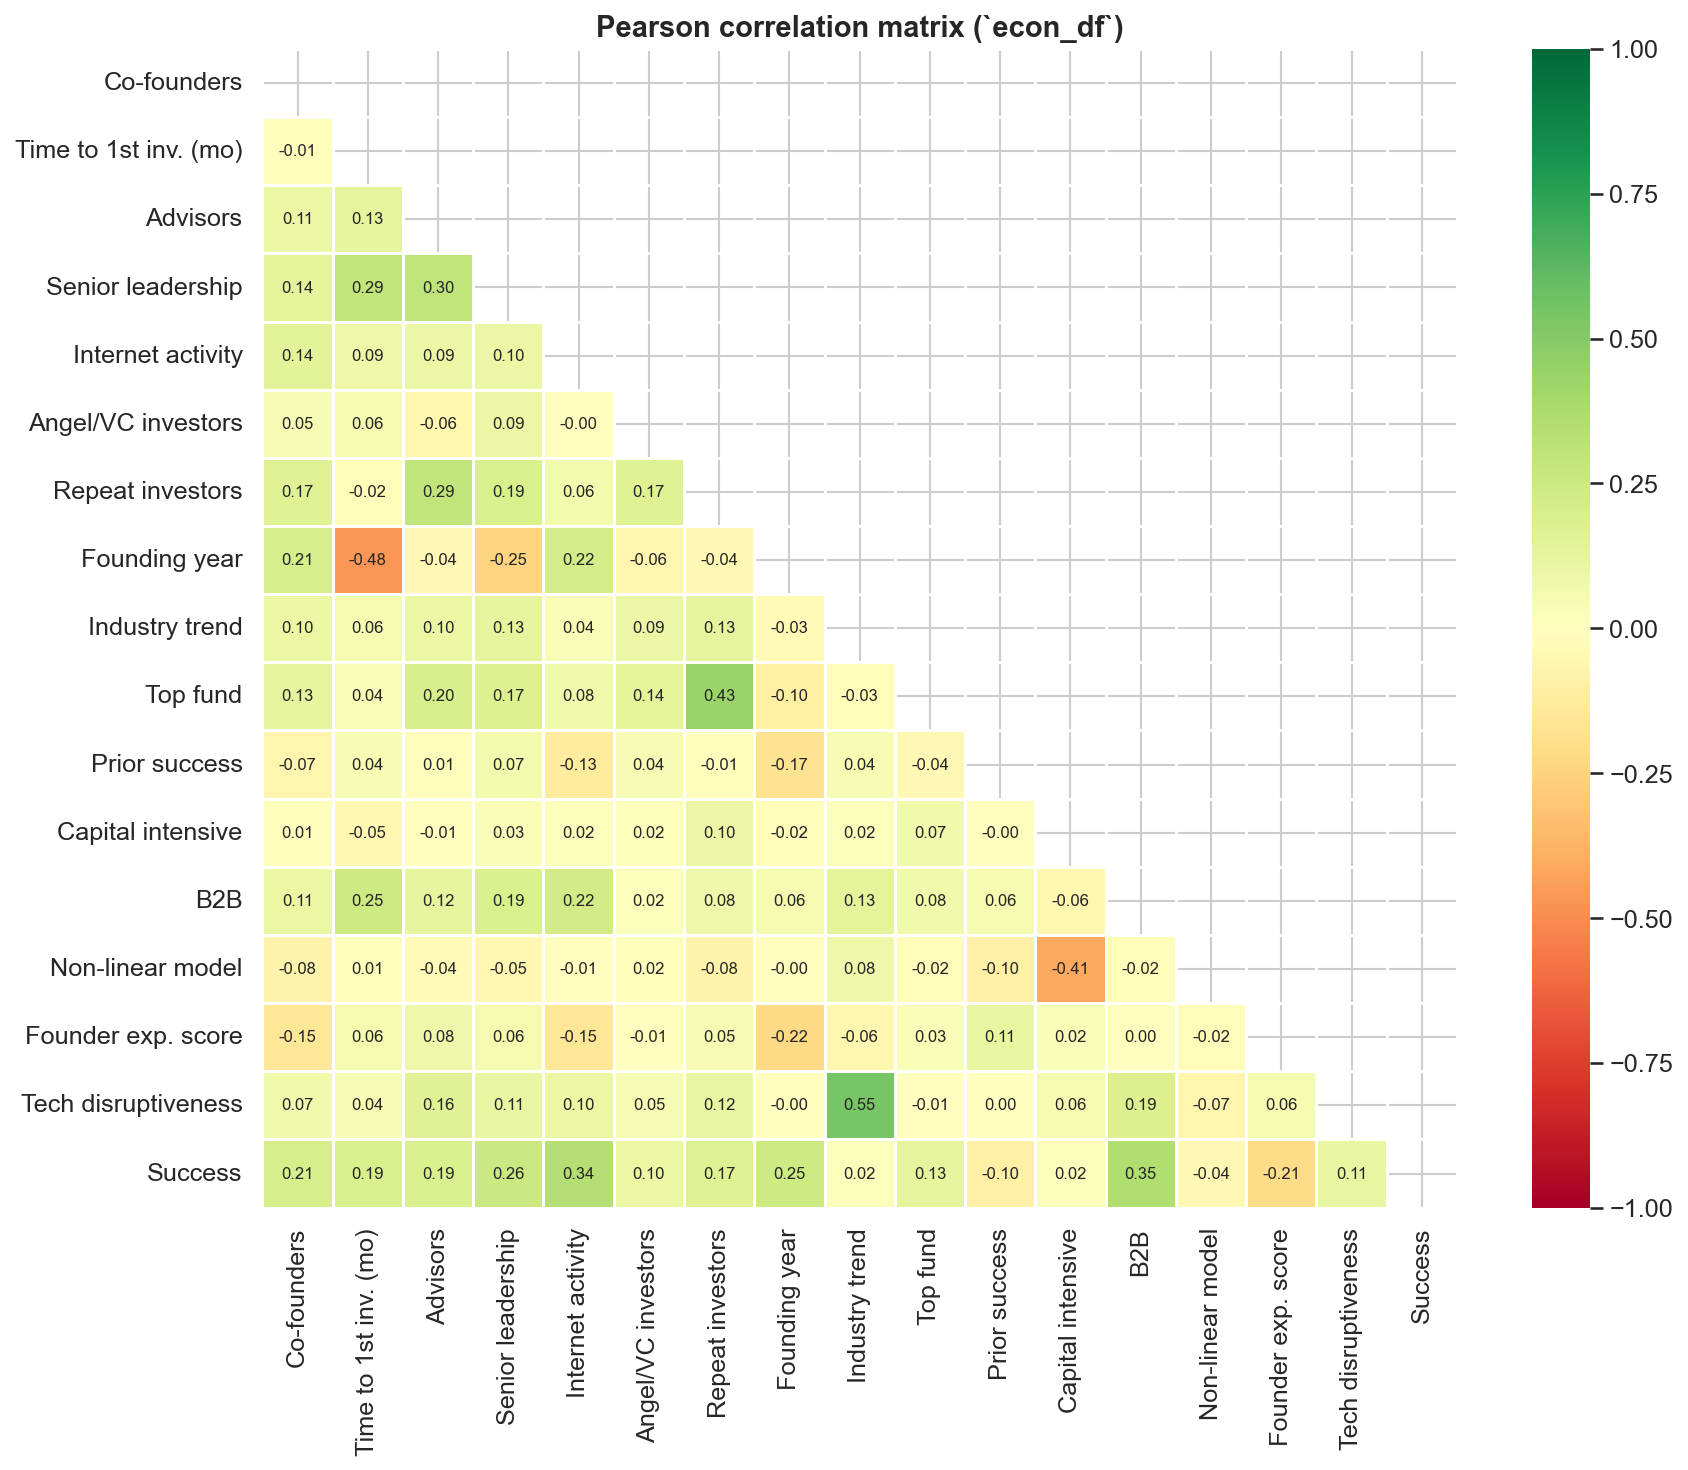

In [51]:
corr_cols = ANALYSIS_FEATURES + ['success']
corr_df = econ_df[corr_cols].copy()
corr_df.columns = [SHORT.get(c, c) for c in corr_df.columns]
corr_mat = corr_df.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10), dpi=FIG_DPI)
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson correlation matrix (`econ_df`)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11 · Feature–Outcome Correlation Ranking

Sorted point-biserial correlations between each `econ_df` predictor and the `success` outcome.

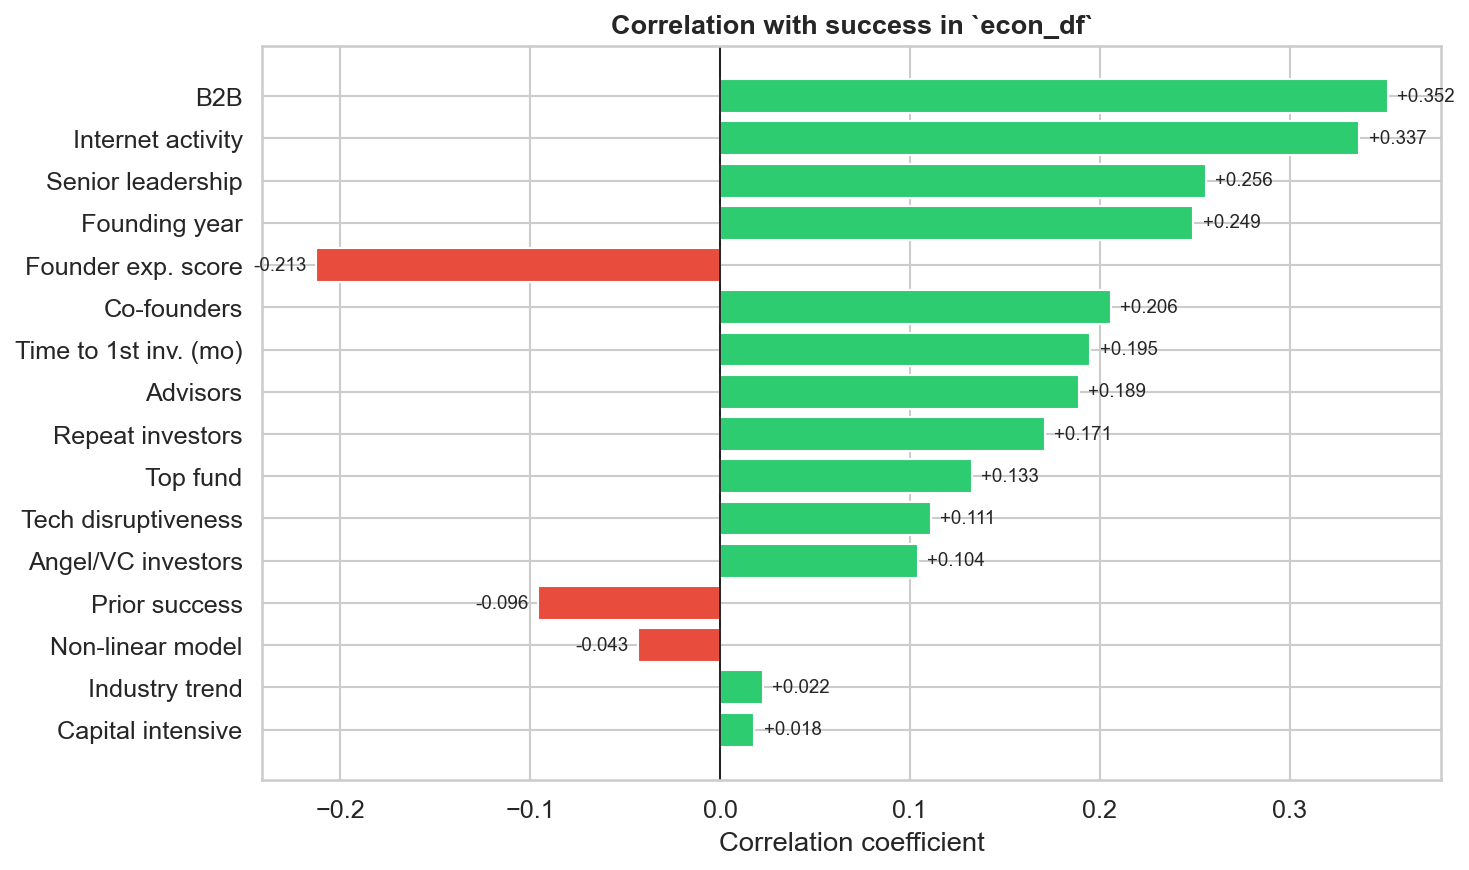

In [52]:
corr_with_target = (
    econ_df[ANALYSIS_FEATURES + ['success']]
    .corr()['success']
    .drop('success')
    .sort_values(key=np.abs, ascending=False)
)

labels = [SHORT.get(c, c) for c in corr_with_target.index]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target.values]

fig, ax = plt.subplots(figsize=(10, 6), dpi=FIG_DPI)
bars = ax.barh(labels, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_with_target.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_title('Correlation with success in `econ_df`', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12 · Cohort Analysis — Founding Year

Founding year remains in `econ_df` after targeted imputation, so we can still study cohort effects on success.

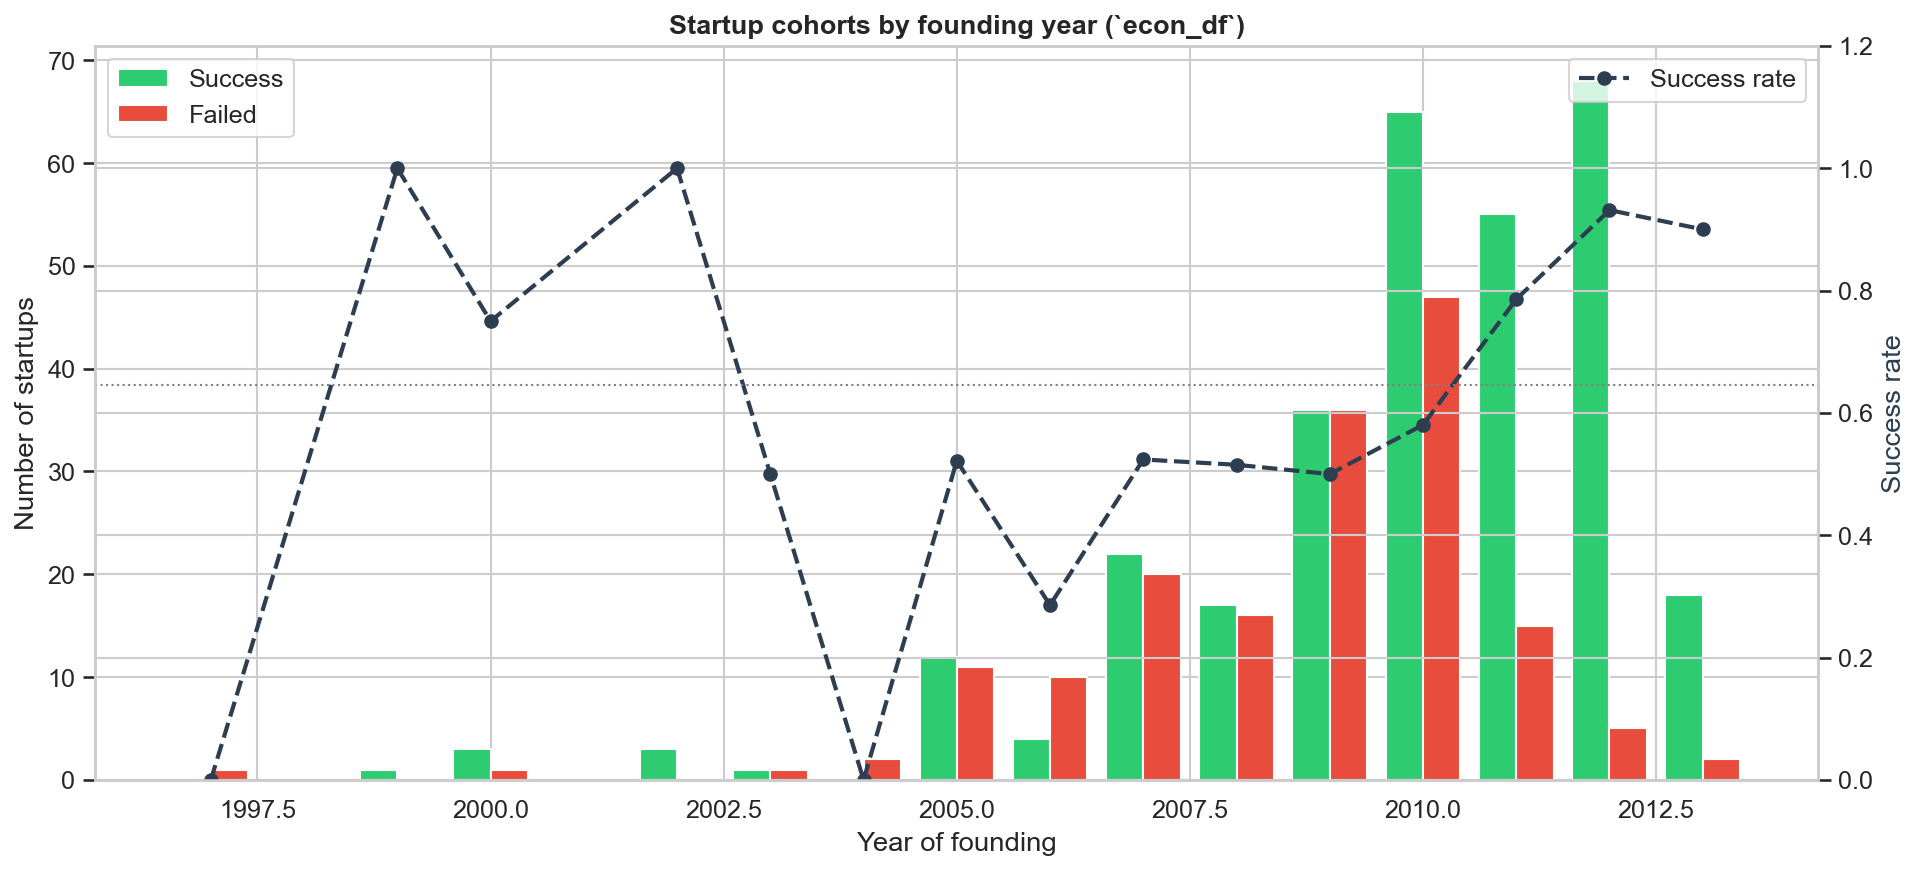

In [53]:
yr = econ_df[['year of founding', 'success']].copy()
yr['year of founding'] = yr['year of founding'].astype(int)
yr_grp = yr.groupby('year of founding')

yr_counts = yr_grp['success'].count()
yr_success = yr_grp['success'].sum()
yr_rates = yr_grp['success'].mean()
yr_failed = yr_counts - yr_success

fig, ax1 = plt.subplots(figsize=(13, 6), dpi=FIG_DPI)

ax1.bar(yr_success.index - 0.2, yr_success.values, width=0.4,
        label='Success', color=PALETTE['Success'], edgecolor='white')
ax1.bar(yr_failed.index + 0.2, yr_failed.values, width=0.4,
        label='Failed', color=PALETTE['Failed'], edgecolor='white')
ax1.set_xlabel('Year of founding')
ax1.set_ylabel('Number of startups')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(yr_rates.index, yr_rates.values, 'o--', color='#2c3e50',
         linewidth=2, markersize=6, label='Success rate')
ax2.axhline(econ_df['success'].mean(), color='grey', linestyle=':', linewidth=1)
ax2.set_ylabel('Success rate', color='#2c3e50')
ax2.set_ylim(0, 1.2)
ax2.legend(loc='upper right')

plt.title('Startup cohorts by founding year (`econ_df`)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13 · Co-founder Count vs. Success Rate

Co-founder count stays in the core `econ_df` feature set, so it remains one of the main hypothesis variables.

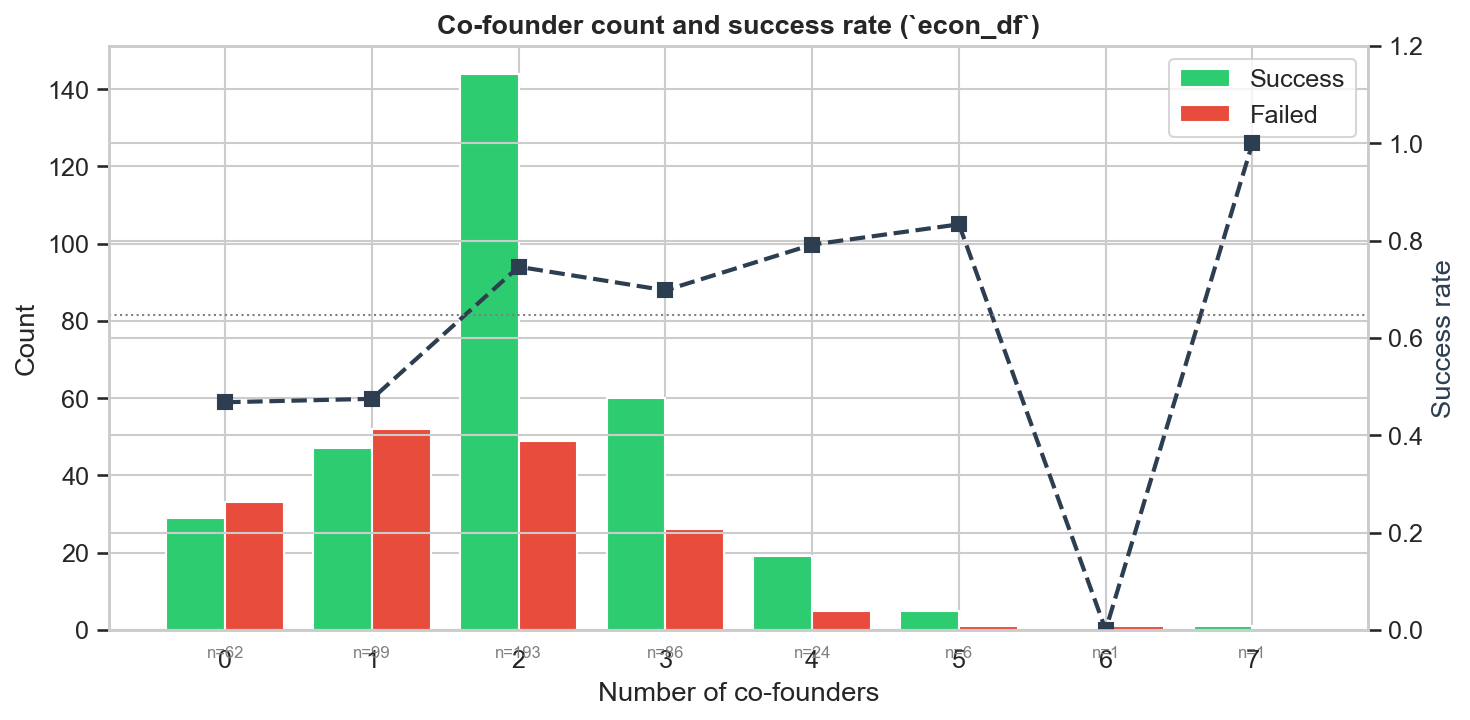

In [54]:
cf = econ_df[['Number of Co-founders', 'success']].copy()
cf['Number of Co-founders'] = cf['Number of Co-founders'].astype(int)
cf_grp = cf.groupby('Number of Co-founders')
cf_rate = cf_grp['success'].mean()
cf_count = cf_grp['success'].count()

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=FIG_DPI)

ax1.bar(cf_count.index - 0.2,
        cf_grp.apply(lambda g: (g['success'] == 1).sum()), width=0.4,
        label='Success', color=PALETTE['Success'], edgecolor='white')
ax1.bar(cf_count.index + 0.2,
        cf_grp.apply(lambda g: (g['success'] == 0).sum()), width=0.4,
        label='Failed', color=PALETTE['Failed'], edgecolor='white')
ax1.set_xlabel('Number of co-founders')
ax1.set_ylabel('Count')
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(cf_rate.index, cf_rate.values, 's--', color='#2c3e50',
         linewidth=2, markersize=7)
ax2.axhline(econ_df['success'].mean(), color='grey', linestyle=':', linewidth=1)
ax2.set_ylabel('Success rate', color='#2c3e50')
ax2.set_ylim(0, 1.2)

for x, n in cf_count.items():
    ax1.text(x, -4, f'n={n}', ha='center', va='top', fontsize=8, color='grey')

plt.title('Co-founder count and success rate (`econ_df`)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14 · Time to First Investment vs. Outcome

This variable remains in `econ_df` and was imputed with group-specific medians, so it can still be analysed as a core timing predictor.

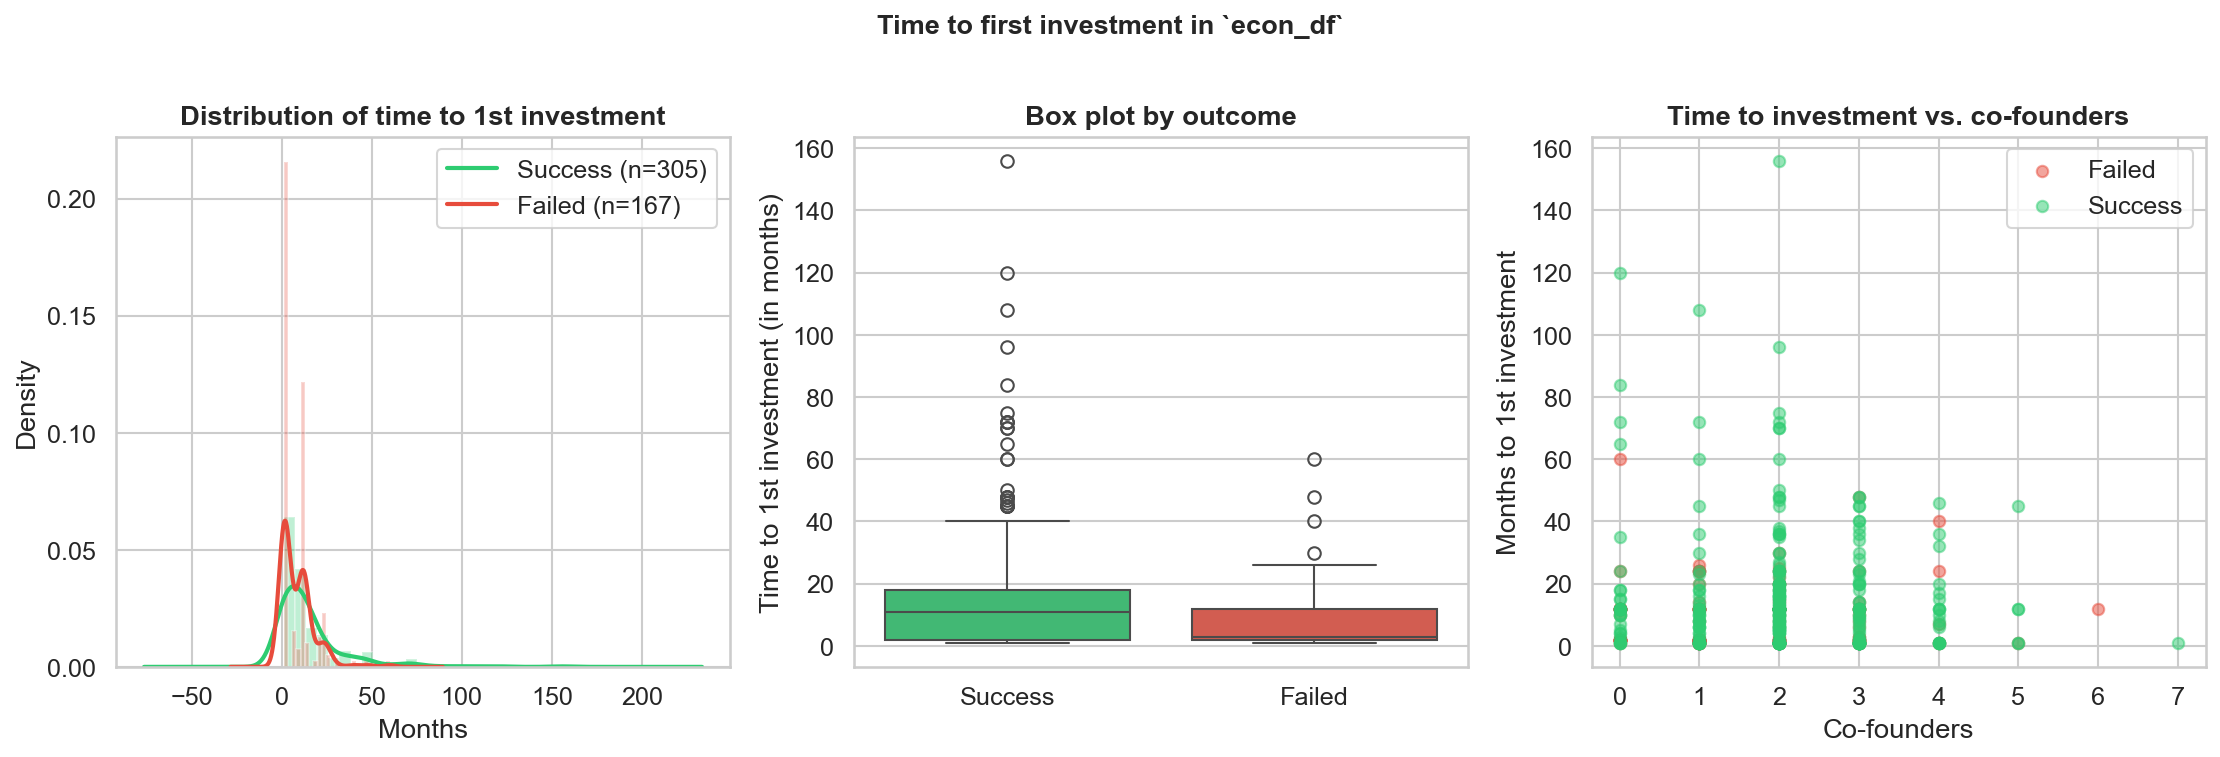

In [55]:
ti = econ_df[['Time to 1st investment (in months)', 'Number of Co-founders', 'success']].copy()

ti_plot = ti.assign(status=ti['success'].map(status_map))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=FIG_DPI)

for status in [1, 0]:
    d = ti.loc[ti['success'] == status, 'Time to 1st investment (in months)']
    if d.nunique() > 5:
        d.plot.kde(ax=axes[0], label=f"{status_map[status]} (n={len(d)})",
                   color=outcome_palette[status], linewidth=2)
    axes[0].hist(d, bins=25, alpha=0.3, density=True, color=outcome_palette[status])
axes[0].set_title('Distribution of time to 1st investment', fontweight='bold')
axes[0].set_xlabel('Months')
axes[0].legend()

sns.boxplot(data=ti_plot, x='status', y='Time to 1st investment (in months)',
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Box plot by outcome', fontweight='bold')
axes[1].set_xlabel('')

for status in [0, 1]:
    sub = ti.loc[ti['success'] == status]
    axes[2].scatter(sub['Number of Co-founders'],
                    sub['Time to 1st investment (in months)'],
                    alpha=0.5, s=30, label=status_map[status], color=outcome_palette[status])
axes[2].set_xlabel('Co-founders')
axes[2].set_ylabel('Months to 1st investment')
axes[2].set_title('Time to investment vs. co-founders', fontweight='bold')
axes[2].legend()

plt.suptitle('Time to first investment in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 15 · Business-Type and Model Dummies

The original business-type labels are now encoded as dummies, so this section compares success rates directly from the numeric regressors.

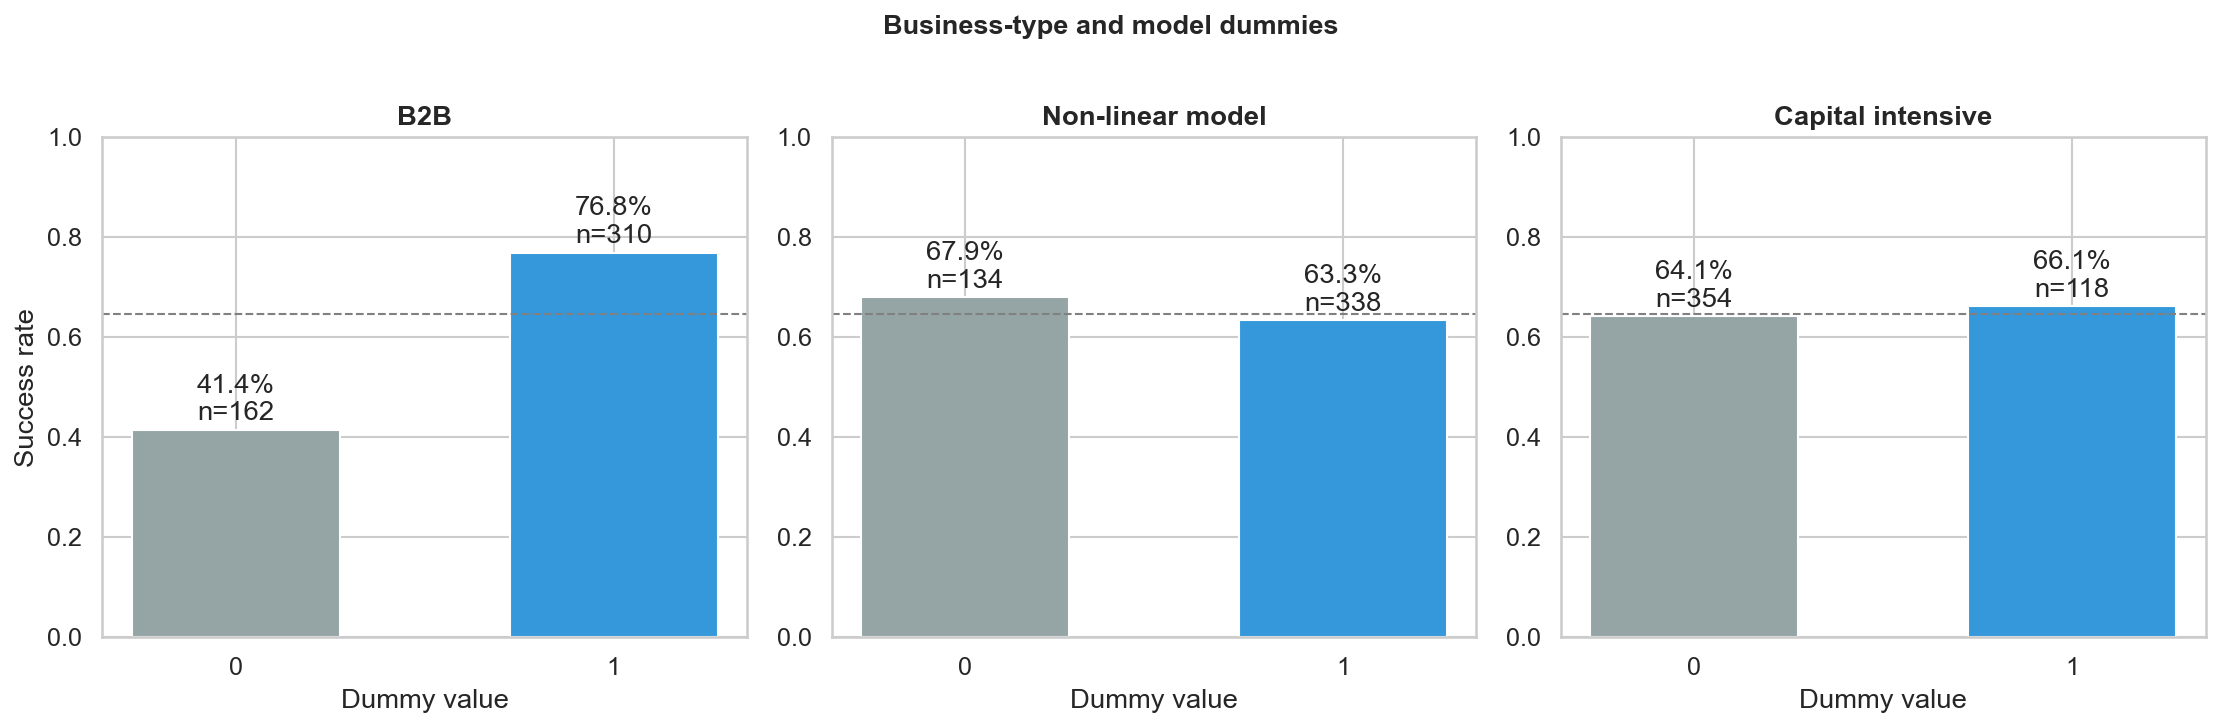

,feature,rate_if_0,rate_if_1,n_if_0,n_if_1
0,d_b2b,0.413580,0.767742,162,310
1,d_nonlinear,0.679104,0.633136,134,338
2,d_capital_intensive,0.641243,0.661017,354,118


In [56]:
dummy_compare = []
for col in ['d_b2b', 'd_nonlinear', 'd_capital_intensive']:
    grp = econ_df.groupby(col)['success'].agg(['mean', 'count'])
    dummy_compare.append({
        'feature': col,
        'rate_if_0': grp.loc[0, 'mean'],
        'rate_if_1': grp.loc[1, 'mean'],
        'n_if_0': int(grp.loc[0, 'count']),
        'n_if_1': int(grp.loc[1, 'count']),
    })

dummy_compare = pd.DataFrame(dummy_compare)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), dpi=FIG_DPI)
for ax, row in zip(axes, dummy_compare.itertuples(index=False)):
    values = [row.rate_if_0, row.rate_if_1]
    counts = [row.n_if_0, row.n_if_1]
    labels = ['0', '1']
    bars = ax.bar(labels, values, color=['#95a5a6', '#3498db'], edgecolor='white', width=0.55)
    for bar, val, n in zip(bars, values, counts):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.1%}\nn={n}', ha='center')
    ax.axhline(econ_df['success'].mean(), color='grey', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(SHORT.get(row.feature, row.feature), fontweight='bold')
    ax.set_xlabel('Dummy value')

axes[0].set_ylabel('Success rate')
plt.suptitle('Business-type and model dummies', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display(dummy_compare)

## 16 · Team Structure Metrics

The team-controls view now excludes employee MoM growth, which was intentionally removed from the econometrics analysis set.

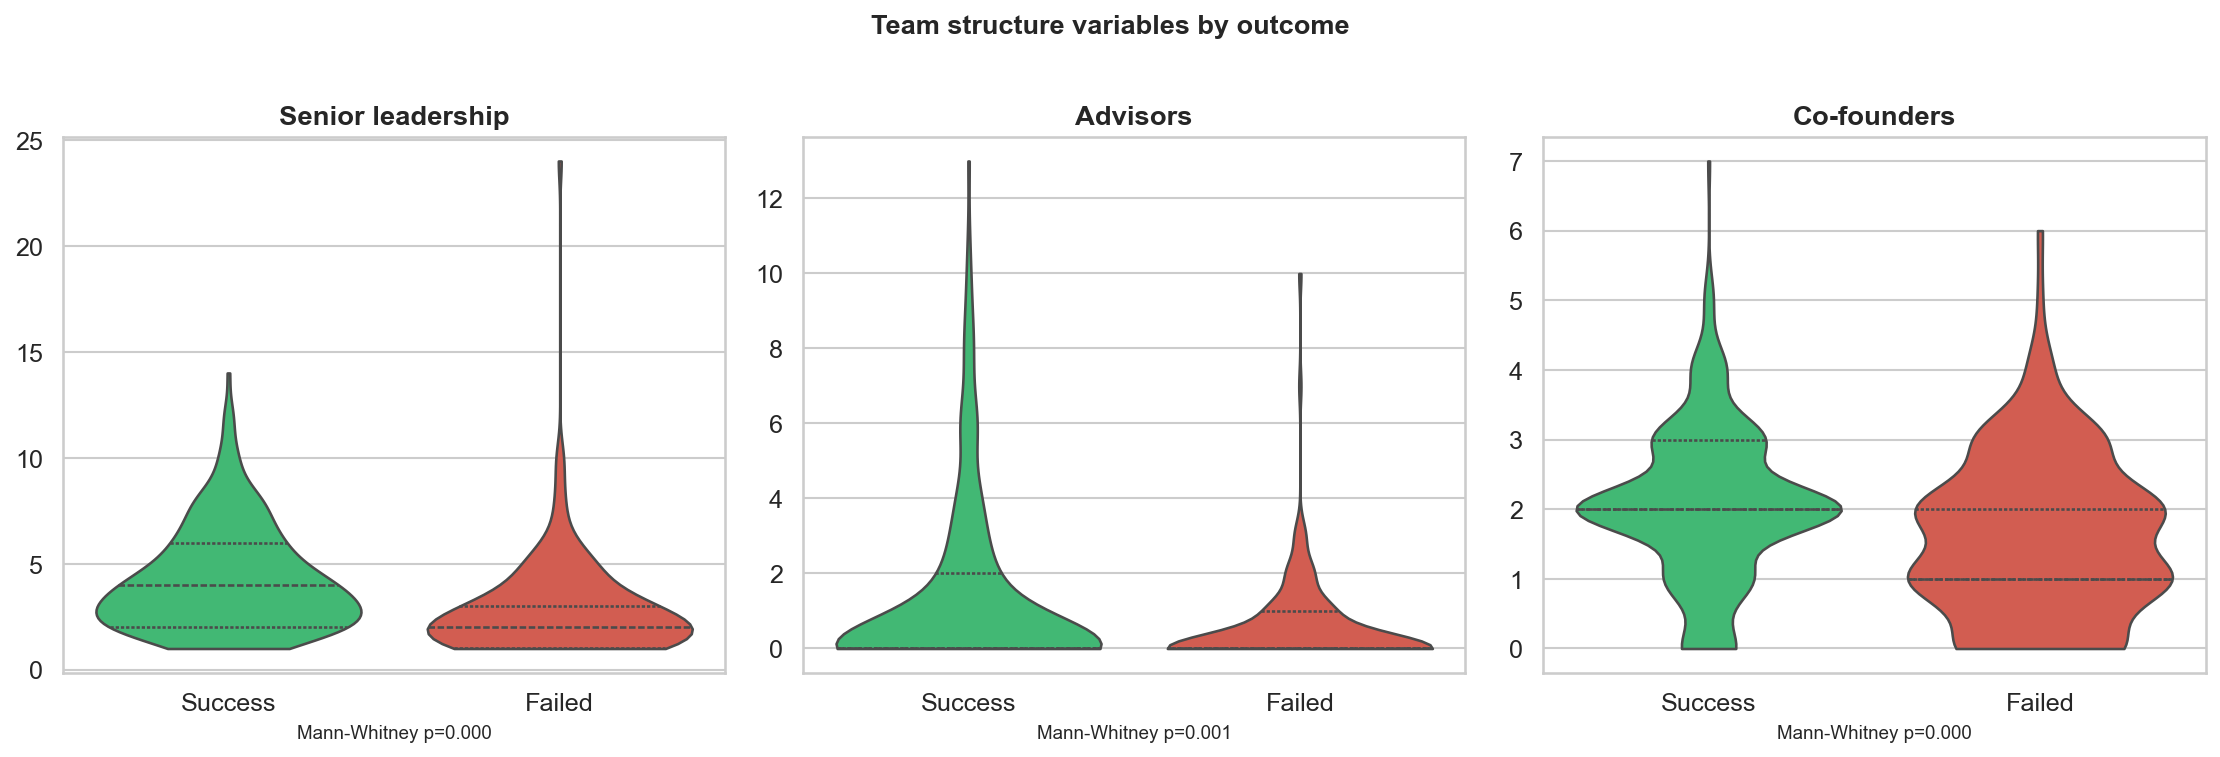

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=FIG_DPI)

team_vars = [
    ('Team size Senior leadership', 'Senior leadership'),
    ('Number of of advisors', 'Advisors'),
    ('Number of Co-founders', 'Co-founders'),
]

team_plot = econ_df.assign(status=econ_df['success'].map(status_map))
for ax, (col, title) in zip(axes, team_vars):
    sns.violinplot(data=team_plot, x='status', y=col,
                   palette=PALETTE, inner='quartile', ax=ax, cut=0)
    s = team_plot.loc[team_plot['success'] == 1, col]
    f = team_plot.loc[team_plot['success'] == 0, col]
    stat, p = stats.mannwhitneyu(s, f, alternative='two-sided')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'Mann-Whitney p={p:.3f}', fontsize=9)
    ax.set_ylabel('')

plt.suptitle('Team structure variables by outcome', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 17 · Encoded Founder-Signal Interactions

After converting founder background variables to scores and dummies, we can inspect their interaction structure numerically.

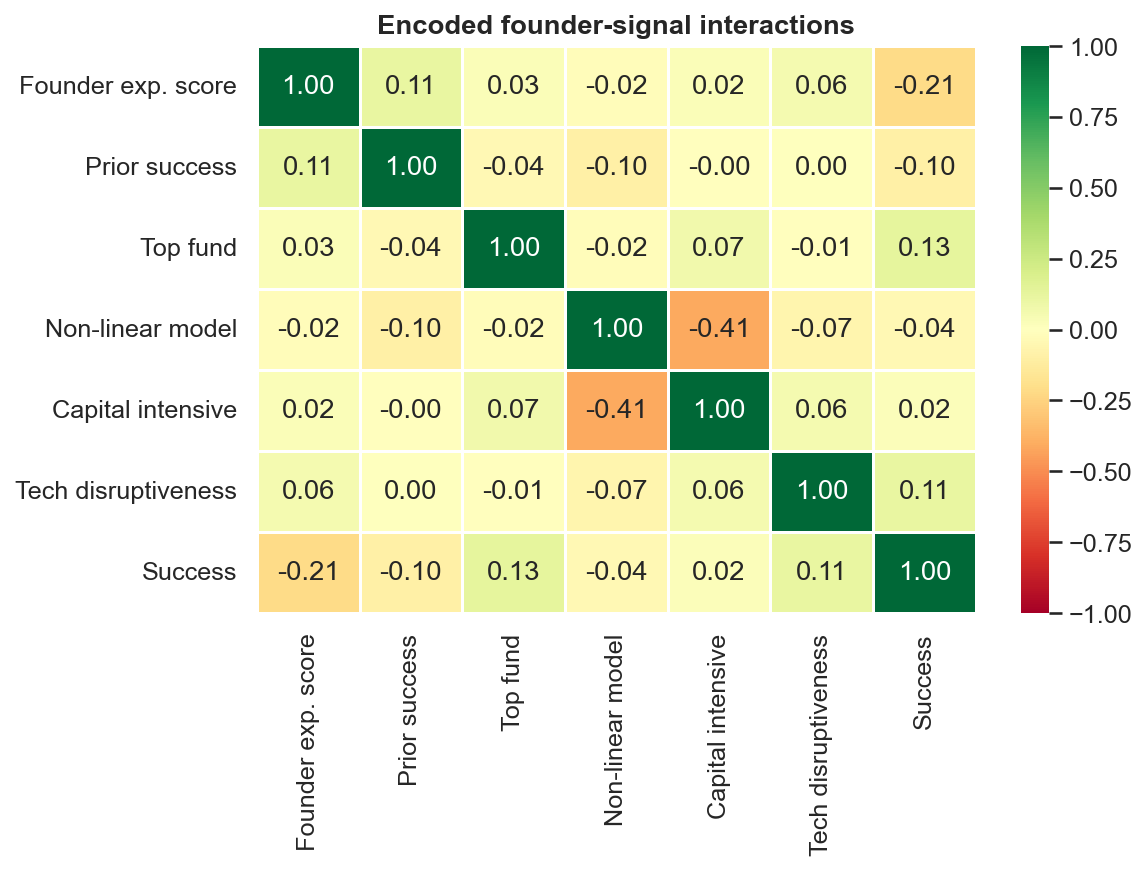

In [58]:
interaction_cols = [
    'founder_experience_score',
    'd_prior_success',
    'd_top_fund',
    'd_nonlinear',
    'd_capital_intensive',
    'tech_disruptiveness_score',
    'success',
]

interaction_corr = econ_df[interaction_cols].corr()
interaction_corr.index = [SHORT.get(c, c) for c in interaction_corr.index]
interaction_corr.columns = [SHORT.get(c, c) for c in interaction_corr.columns]

fig, ax = plt.subplots(figsize=(8, 6), dpi=FIG_DPI)
sns.heatmap(interaction_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Encoded founder-signal interactions', fontweight='bold')
plt.tight_layout()
plt.show()

## 18 · Internet Activity Score — Deep Dive

Internet activity remains one of the strongest numeric predictors in `econ_df`, so it still deserves a closer look.

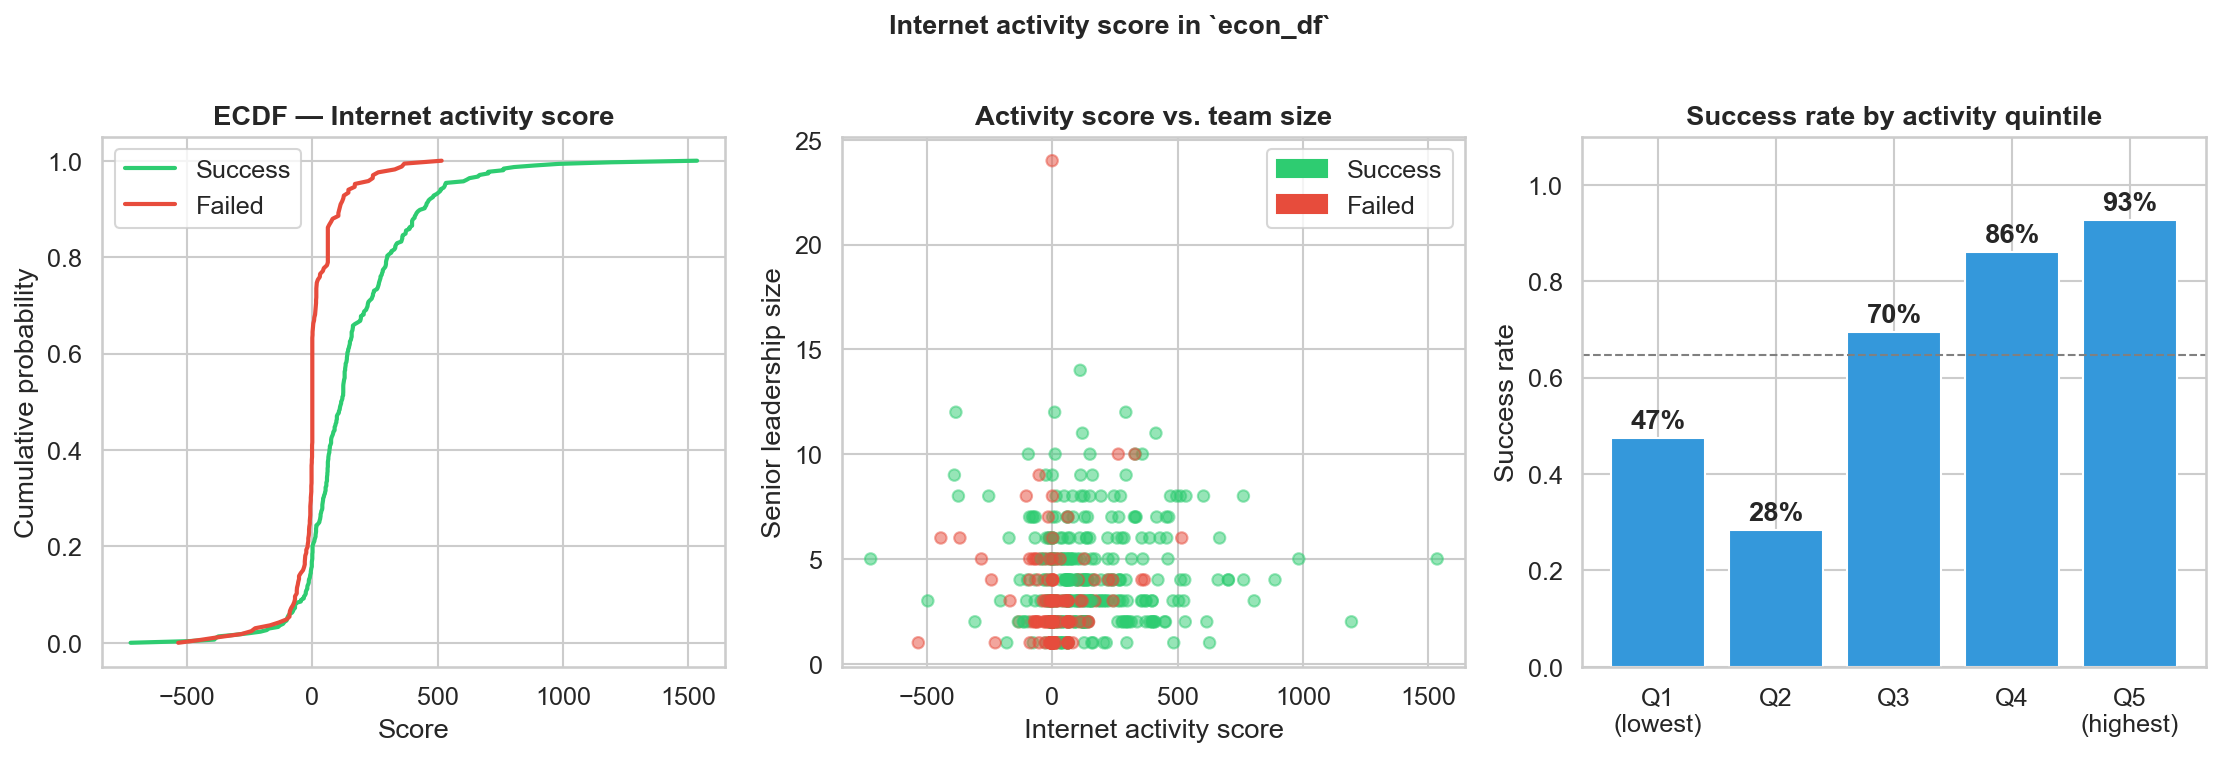

In [59]:
ia = econ_df[['Internet Activity Score', 'success', 'Team size Senior leadership', 'Number of Co-founders']].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=FIG_DPI)

for status in [1, 0]:
    d = ia.loc[ia['success'] == status, 'Internet Activity Score'].sort_values()
    axes[0].plot(d, np.linspace(0, 1, len(d)), label=status_map[status],
                 color=outcome_palette[status], linewidth=2)
axes[0].set_title('ECDF — Internet activity score', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Cumulative probability')
axes[0].legend()

axes[1].scatter(ia['Internet Activity Score'], ia['Team size Senior leadership'],
                c=ia['success'].map(outcome_palette), alpha=0.5, s=30)
axes[1].set_xlabel('Internet activity score')
axes[1].set_ylabel('Senior leadership size')
axes[1].set_title('Activity score vs. team size', fontweight='bold')
success_patch = mpatches.Patch(color=PALETTE['Success'], label='Success')
failed_patch = mpatches.Patch(color=PALETTE['Failed'], label='Failed')
axes[1].legend(handles=[success_patch, failed_patch])

ia2 = ia.copy()
ia2['IA_bin'] = pd.qcut(ia2['Internet Activity Score'], q=5,
                        labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
bin_rate = ia2.groupby('IA_bin')['success'].mean()
axes[2].bar(bin_rate.index.astype(str), bin_rate.values,
            color='#3498db', edgecolor='white')
axes[2].axhline(econ_df['success'].mean(), color='grey', linestyle='--', linewidth=1)
for i, v in enumerate(bin_rate.values):
    axes[2].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
axes[2].set_title('Success rate by activity quintile', fontweight='bold')
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('Success rate')

plt.suptitle('Internet activity score in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 19 · Pairplot — Top 5 Predictors

Scatter-matrix of the five `econ_df` predictors most correlated with success, coloured by the binary outcome.

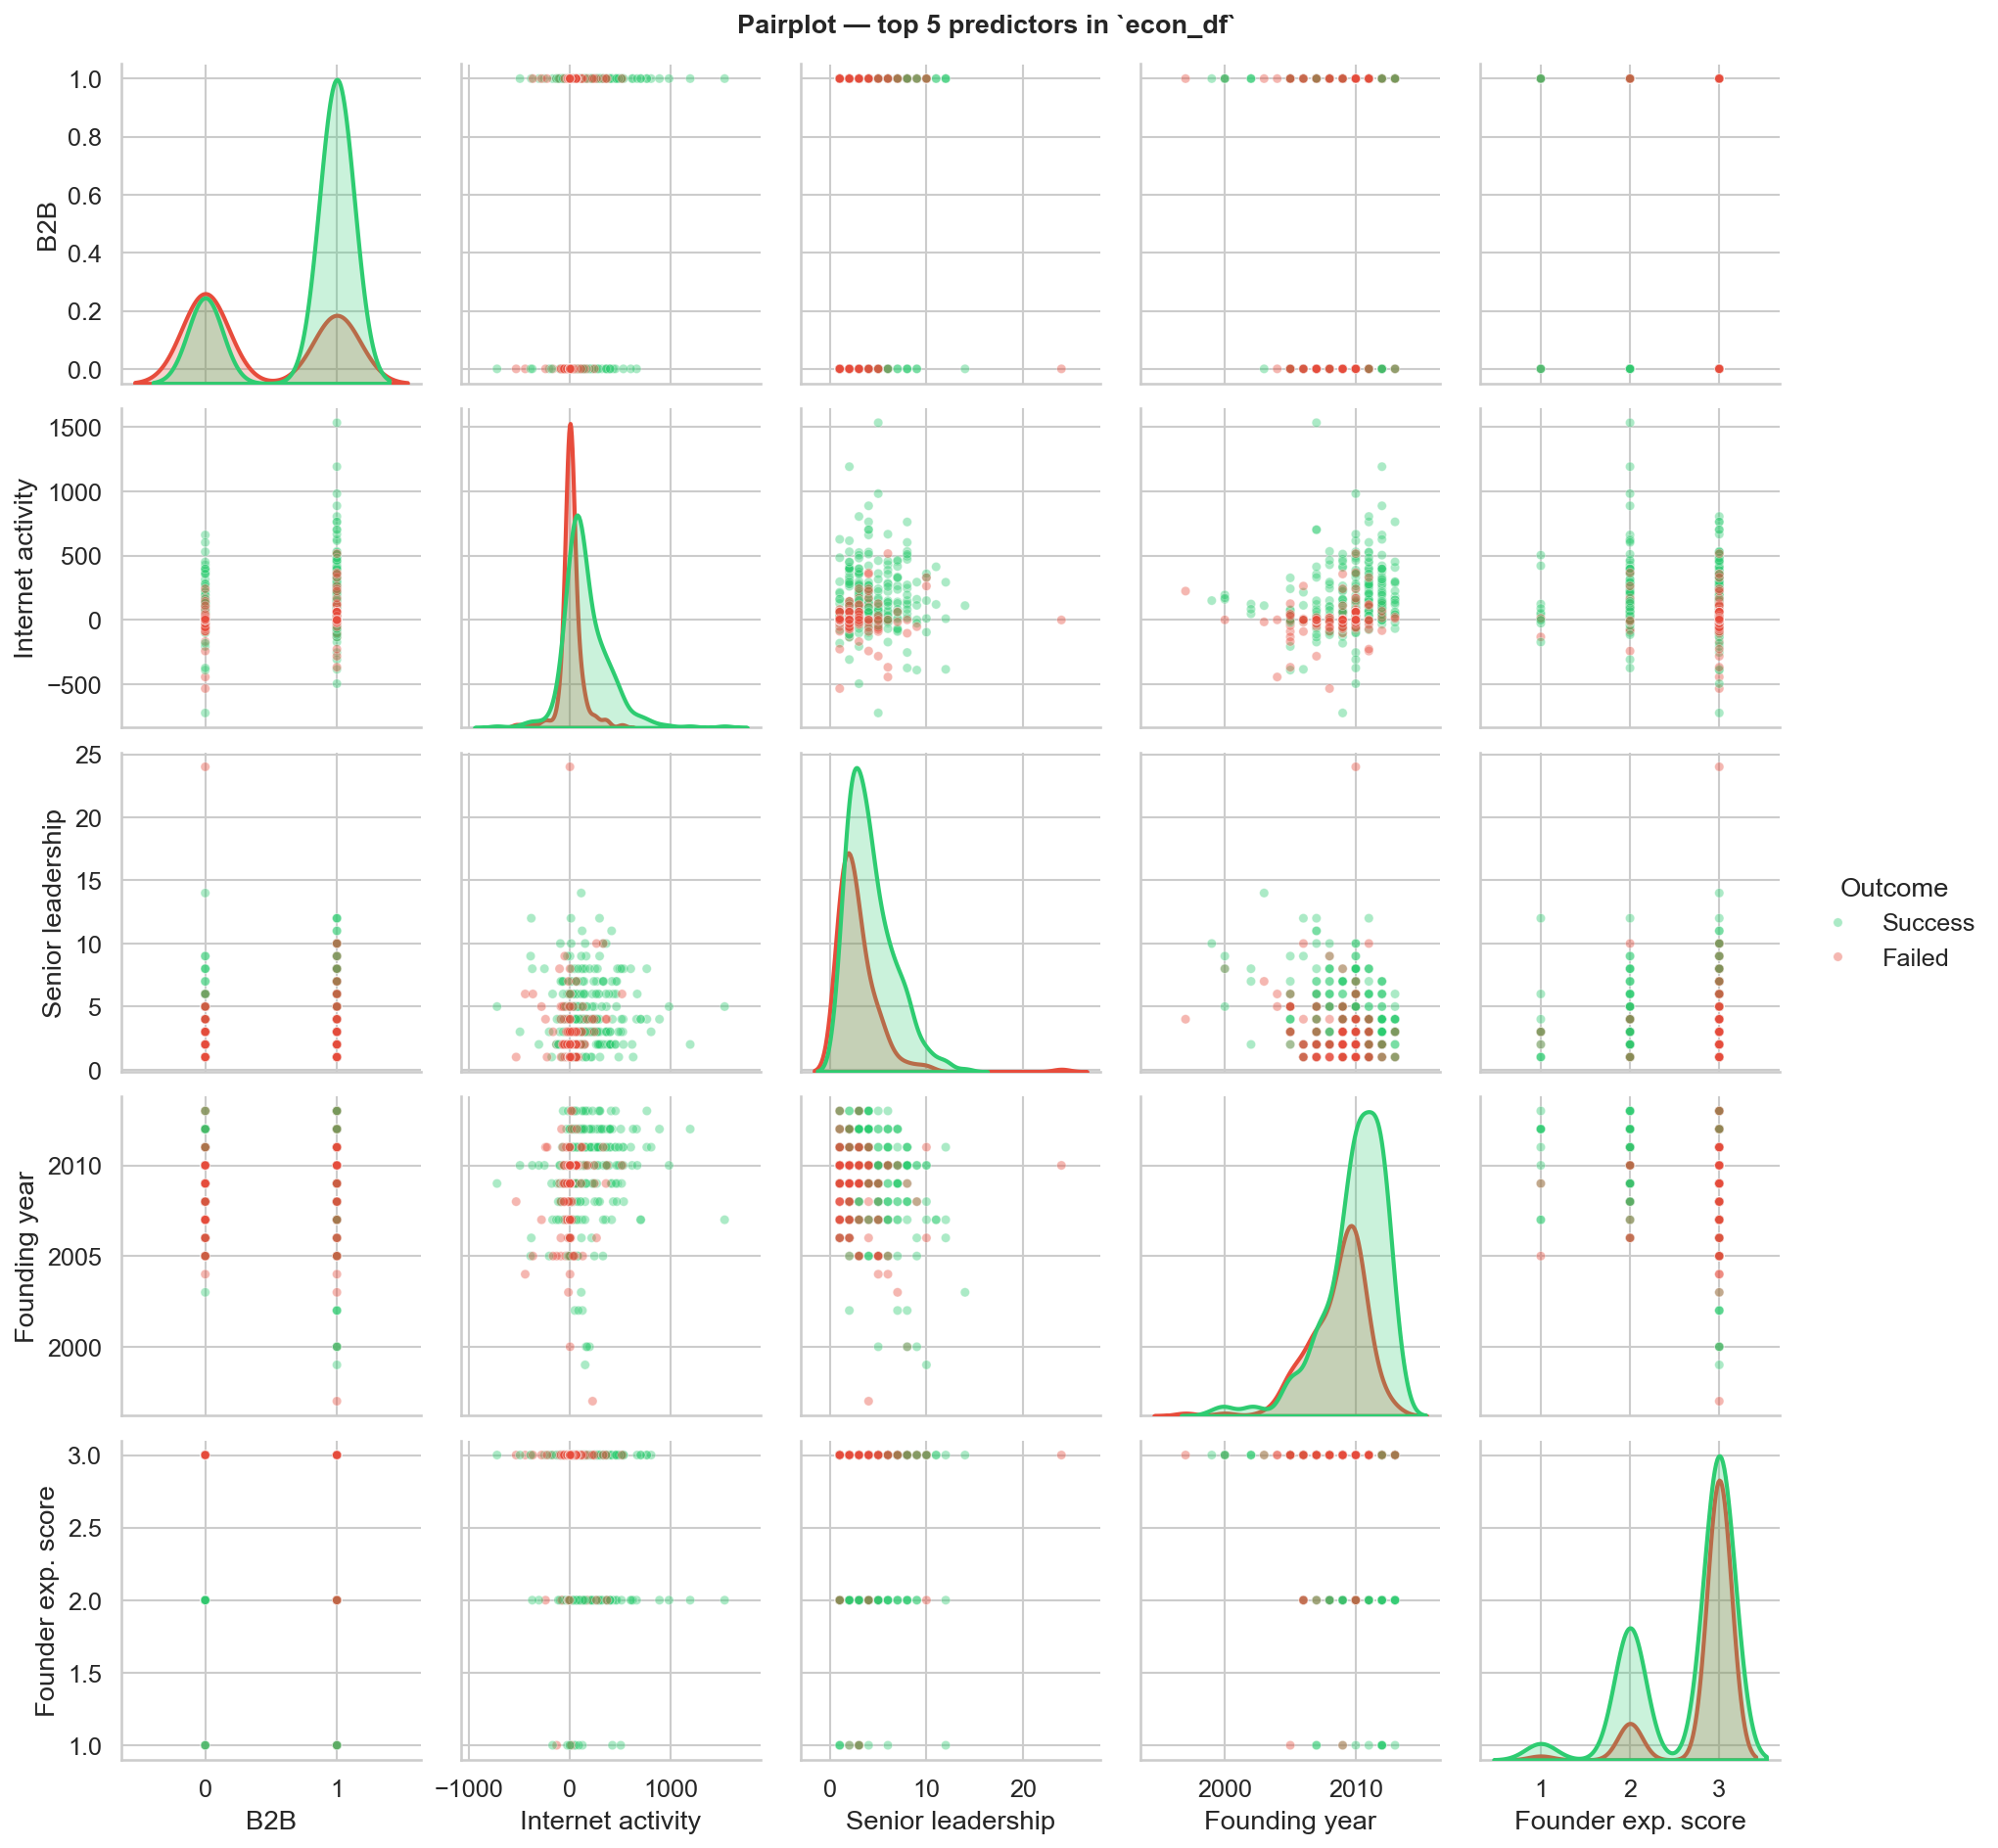

In [60]:
top5 = corr_with_target.head(5).index.tolist()
pair_df = econ_df[top5 + ['success']].copy()
pair_df['Outcome'] = pair_df['success'].map(status_map)
pair_df = pair_df.drop(columns='success')
pair_df.columns = [SHORT.get(c, c) if c != 'Outcome' else c for c in pair_df.columns]

g = sns.pairplot(pair_df, hue='Outcome',
                 palette=PALETTE, diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kws={'linewidth': 2})
g.figure.suptitle('Pairplot — top 5 predictors in `econ_df`',
                  fontsize=13, fontweight='bold', y=1.01)
g.figure.set_dpi(FIG_DPI)
plt.show()

## 20 · Investor Signals

Investor-related variables remain in `econ_df` except the removed funding amount, so this section focuses on counts and the top-fund dummy.

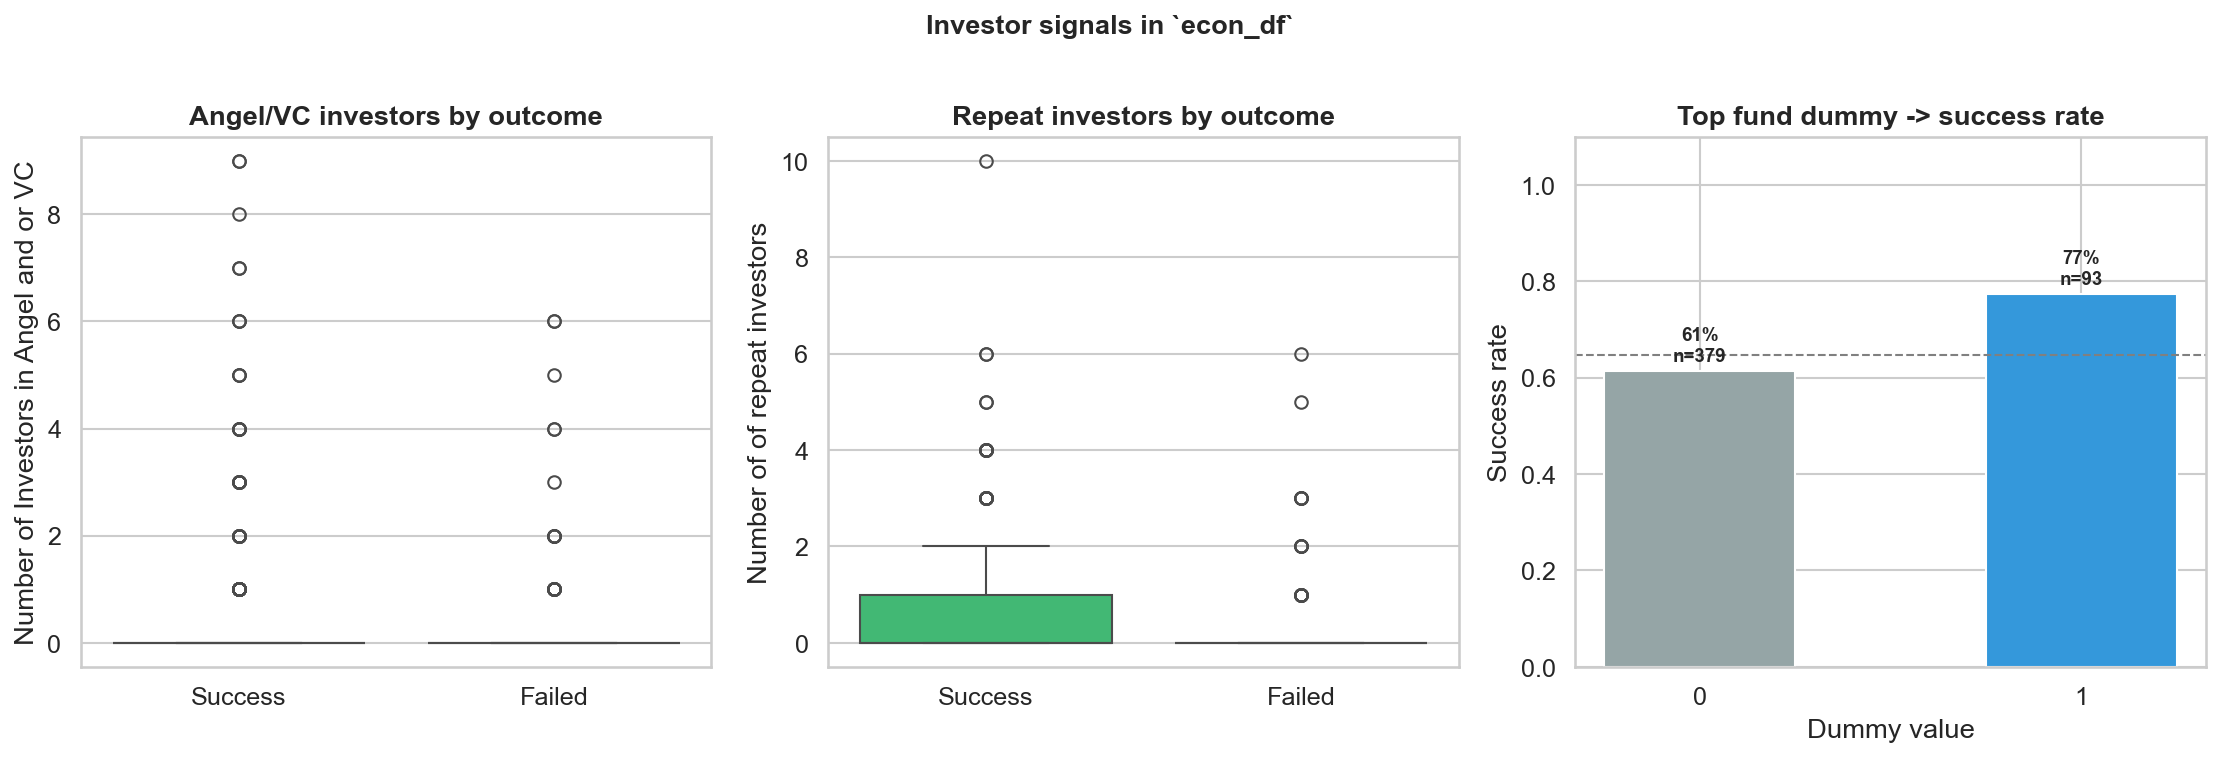

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=FIG_DPI)

inv = econ_df.assign(status=econ_df['success'].map(status_map))
sns.boxplot(data=inv, x='status', y='Number of Investors in Angel and or VC',
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Angel/VC investors by outcome', fontweight='bold')
axes[0].set_xlabel('')

sns.boxplot(data=inv, x='status', y='Number of of repeat investors',
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Repeat investors by outcome', fontweight='bold')
axes[1].set_xlabel('')

tf_rate = econ_df.groupby('d_top_fund')['success'].agg(['mean', 'count'])
bars = axes[2].bar(['0', '1'], tf_rate['mean'], color=['#95a5a6', '#3498db'],
                   edgecolor='white', width=0.5)
axes[2].axhline(econ_df['success'].mean(), color='grey', linestyle='--', linewidth=1)
for bar, (_, row) in zip(bars, tf_rate.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2, row['mean'] + 0.02,
                 f"{row['mean']:.0%}\nn={int(row['count'])}",
                 ha='center', fontsize=9, fontweight='bold')
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Top fund dummy -> success rate', fontweight='bold')
axes[2].set_ylabel('Success rate')
axes[2].set_xlabel('Dummy value')

plt.suptitle('Investor signals in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 21 · Business Model Interaction

The business-model and capital-intensity variables now enter the notebook as dummies, so we inspect their interaction numerically.

TypeError: Image data of dtype object cannot be converted to float

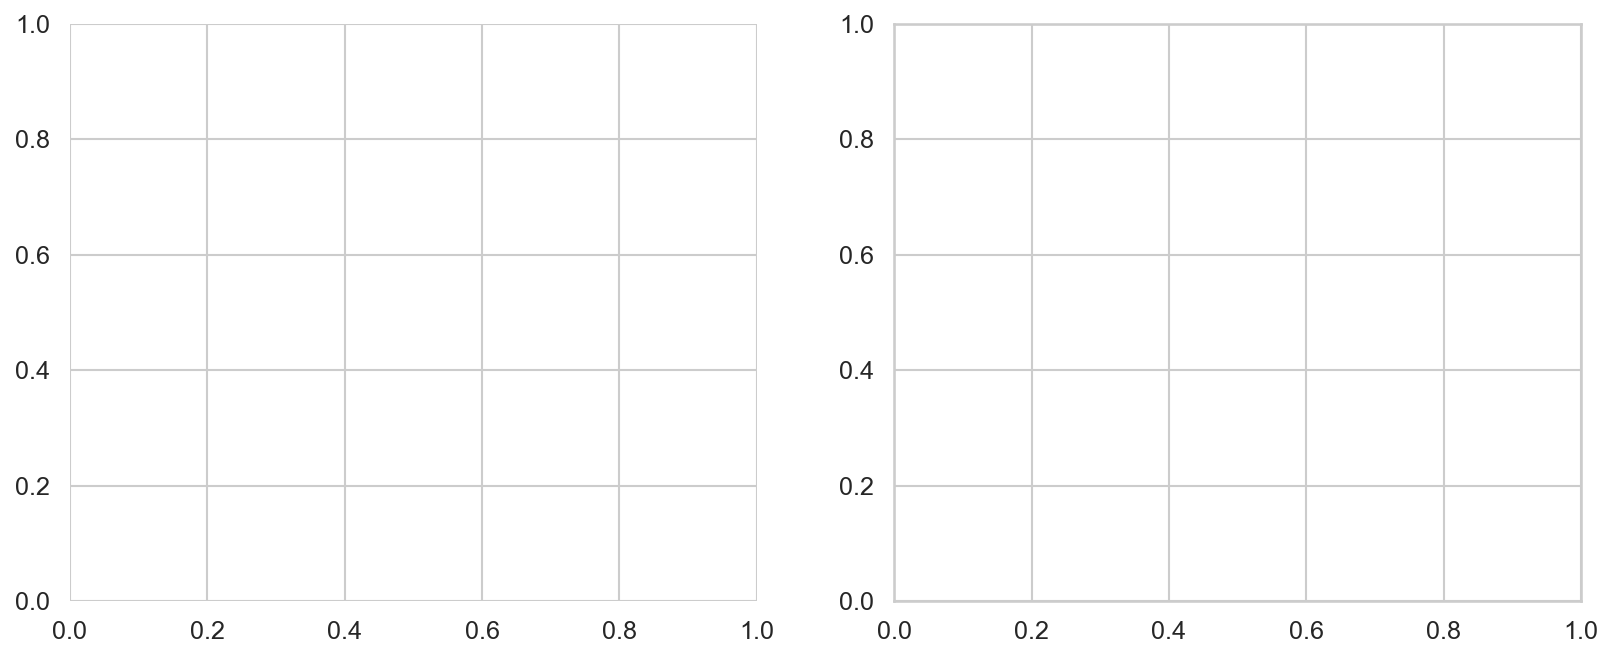

In [62]:
bm = econ_df[['d_nonlinear', 'd_capital_intensive', 'success']].copy()
pivot = bm.groupby(['d_nonlinear', 'd_capital_intensive'])['success'].mean().unstack()
pivot.index = ['Linear', 'Non-linear']
pivot.columns = ['Not capital-intensive', 'Capital-intensive']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=FIG_DPI)

sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=1, ax=axes[0], cbar=True)
axes[0].set_title('Success rate:\nmodel x capital intensity', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

bm_rate = bm.groupby(['d_nonlinear', 'd_capital_intensive'])['success'].mean().reset_index()
bm_rate.columns = ['model_dummy', 'capital_dummy', 'success_rate']
x = np.arange(2)
width = 0.35
for i, cap in enumerate([0, 1]):
    vals = [bm_rate.loc[(bm_rate['model_dummy'] == m) & (bm_rate['capital_dummy'] == cap), 'success_rate'].values
            for m in [0, 1]]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    axes[1].bar(x + i * width, vals, width, label=f'Capital dummy={cap}',
                color=['#74b9ff', '#fd79a8'][i], edgecolor='white')
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(['Linear', 'Non-linear'])
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Success rate')
axes[1].set_title('Success rate by encoded business model terms', fontweight='bold')
axes[1].legend()
axes[1].axhline(econ_df['success'].mean(), color='grey', linestyle='--', linewidth=1)

plt.suptitle('Business model x capital intensity in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 22 · Industry Investment Trend

Industry trend stays in `econ_df` as a numeric ordinal score, so we can examine it directly without the original text categories.

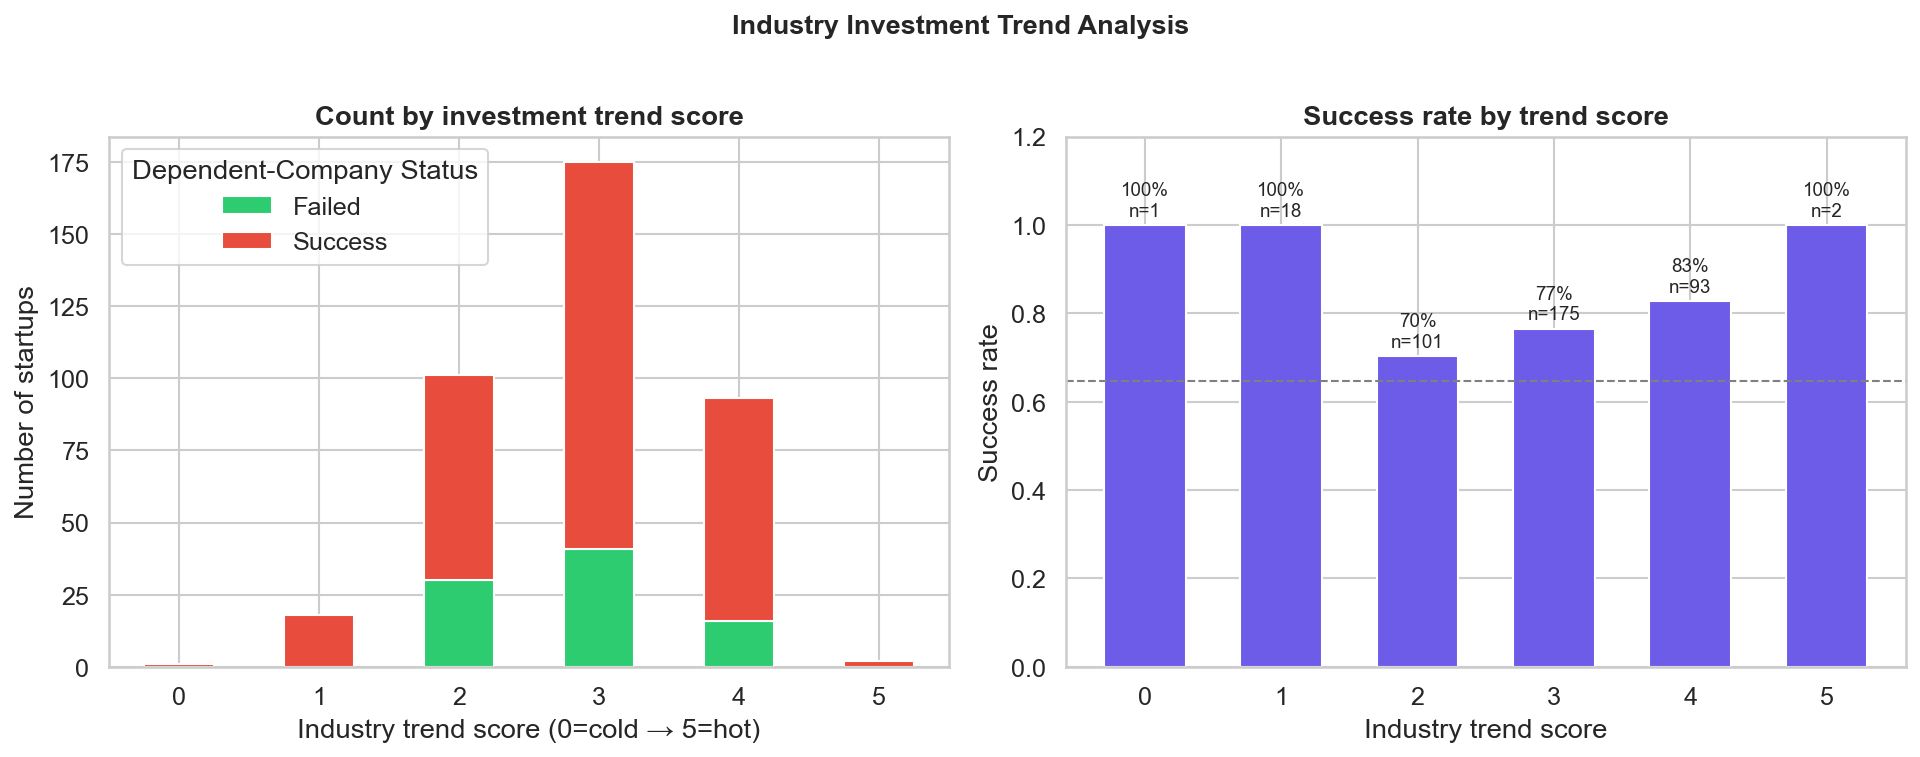

In [ ]:
it = econ_df[['Industry trend in investing', 'success']].copy()
it['trend_int'] = it['Industry trend in investing'].astype(int)
it['status'] = it['success'].map(status_map)

trend_ct = it.groupby(['trend_int', 'status']).size().unstack(fill_value=0)
trend_rate = it.groupby('trend_int')['success'].mean()
trend_n = it.groupby('trend_int')['success'].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=FIG_DPI)

trend_ct = trend_ct.reindex(columns=['Success', 'Failed'])
trend_ct.plot(kind='bar', stacked=True, ax=axes[0],
              color=[PALETTE['Success'], PALETTE['Failed']], edgecolor='white')
axes[0].set_title('Count by industry trend score', fontweight='bold')
axes[0].set_xlabel('Industry trend score')
axes[0].set_ylabel('Number of startups')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(trend_rate.index, trend_rate.values,
            color='#6c5ce7', edgecolor='white', width=0.6)
axes[1].axhline(econ_df['success'].mean(), color='grey', linestyle='--', linewidth=1)
for x, (r, n) in zip(trend_rate.index, zip(trend_rate.values, trend_n.values)):
    axes[1].text(x, r + 0.02, f'{r:.0%}\nn={n}', ha='center', fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Success rate by industry trend score', fontweight='bold')
axes[1].set_xlabel('Industry trend score')
axes[1].set_ylabel('Success rate')

plt.suptitle('Industry investment trend in `econ_df`', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 23 · EDA Summary

Compact statistical summary for the final `econ_df` analysis frame.

In [ ]:
print('=' * 65)
print('EDA SUMMARY STATISTICS — ECON_DF')
print('=' * 65)

print(f"\nDataset: {econ_df.shape[0]} startups | {len(ANALYSIS_FEATURES)} predictors")
print(f"Outcome: Success={econ_df['success'].sum()} ({econ_df['success'].mean():.1%}) | "
      f"Failed={(econ_df['success'] == 0).sum()} ({1 - econ_df['success'].mean():.1%})")
print(f"Removed variables: Last funding, Employee MoM change, Univ. tier")
print(f"Remaining missing cells after imputation: {int(missing_after_imputation.sum())}")

print('\n── Correlations with success (|r| ranked) ──────────────────')
for col, r in corr_with_target.items():
    print(f"  {SHORT.get(col, col):<35s}  r = {r:+.3f}")

print('\n── Mann-Whitney U tests (continuous / ordinal vars) ───────')
for col in NUM_FEATURES:
    s = econ_df.loc[econ_df['success'] == 1, col].dropna()
    f = econ_df.loc[econ_df['success'] == 0, col].dropna()
    if len(s) > 5 and len(f) > 5:
        stat, p = stats.mannwhitneyu(s, f, alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {SHORT.get(col, col):<35s}  p={p:.4f} {sig}")

print('\n── Difference in means for dummy vars ─────────────────────')
for col in BINARY_FEATURES:
    grp = econ_df.groupby(col)['success'].mean()
    diff = grp.loc[1] - grp.loc[0]
    print(f"  {SHORT.get(col, col):<35s}  lift = {diff:+.3f}")

print('\n* p<.05  ** p<.01  *** p<.001')
print('=' * 65)

EDA SUMMARY STATISTICS

Dataset: 472 startups | 20 features
Outcome: Success=305 (64.6%) | Failed=167 (35.4%)

── Numeric correlations with success (|r| ranked) ──────────
  Internet Activity                    r = +0.327
  Employee MoM Δ (%)                   r = +0.277
  Senior leadership                    r = +0.256
  Co-founders                          r = +0.206
  Advisors                             r = +0.189
  Repeat investors                     r = +0.124
  Time to 1st inv. (mo)                r = +0.101
  Angel/VC investors                   r = +0.055
  Inv. trend (0-5)                     r = +0.032
  Last funding (M$)                    r = +0.019

── Mann-Whitney U tests (numeric vars) ─────────────────────
  Co-founders                          p=0.0000 ***
  Time to 1st inv. (mo)                p=0.0733 
  Advisors                             p=0.0008 ***
  Senior leadership                    p=0.0000 ***
  Employee MoM Δ (%)                   p=0.0009 ***
  Interne

## 24 · Key Findings Summary Chart

A final one-page overview of the strongest `econ_df` correlations and the largest dummy-variable success lifts.

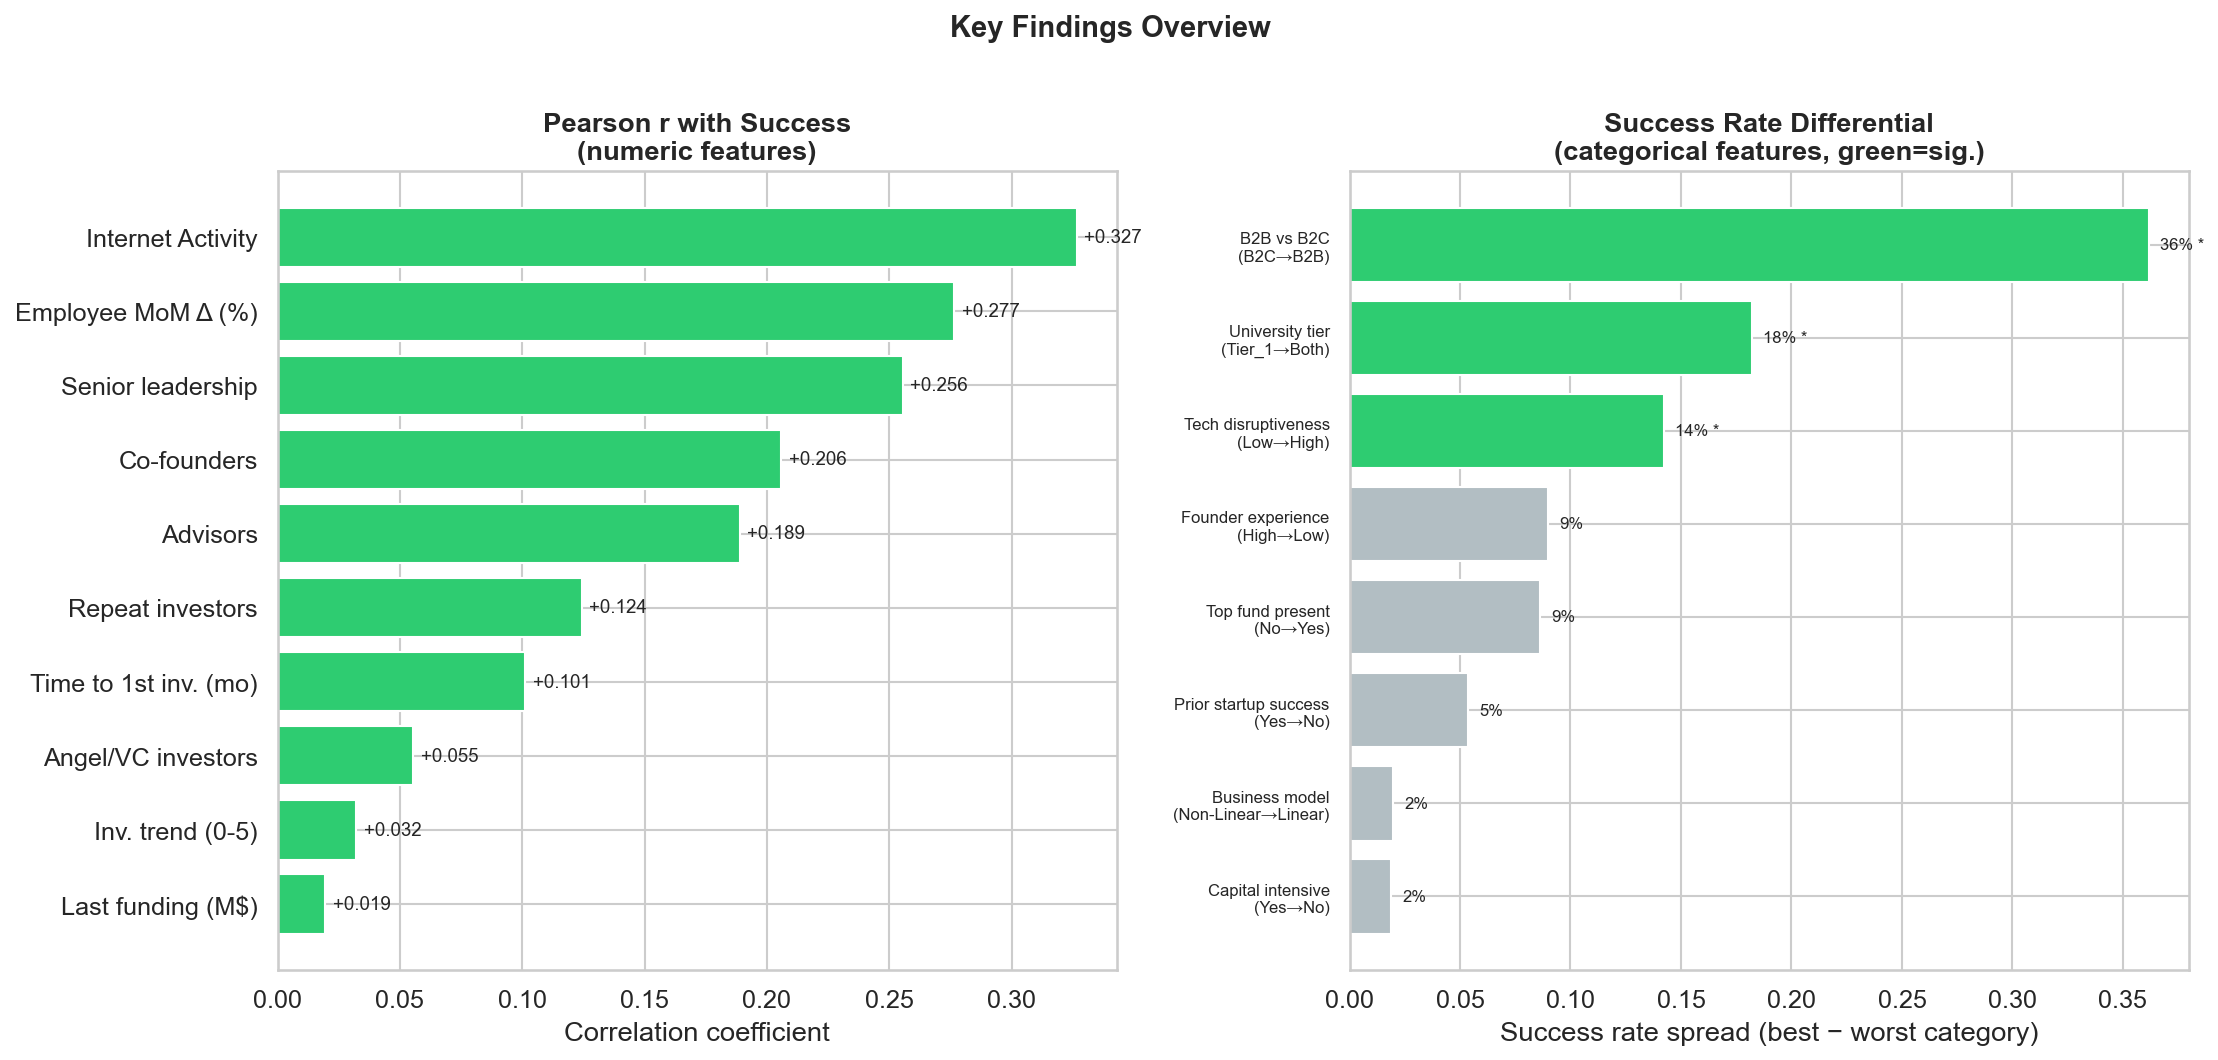

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=FIG_DPI)

corr_sorted = corr_with_target.sort_values(ascending=True)
clrs = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_sorted.values]
axes[0].barh([SHORT.get(c, c) for c in corr_sorted.index],
             corr_sorted.values, color=clrs, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
for i, (col, v) in enumerate(corr_sorted.items()):
    axes[0].text(v + (0.003 if v >= 0 else -0.003), i, f'{v:+.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)
axes[0].set_title('Correlation with success', fontweight='bold')
axes[0].set_xlabel('Correlation coefficient')

lift_df = binary_lift.sort_values('lift', ascending=True)
axes[1].barh([SHORT.get(c, c) for c in lift_df['feature']], lift_df['lift'],
             color=['#2ecc71' if v > 0 else '#e74c3c' for v in lift_df['lift']],
             edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
for i, (_, row) in enumerate(lift_df.iterrows()):
    axes[1].text(row['lift'] + (0.005 if row['lift'] >= 0 else -0.005), i,
                 f"{row['lift']:+.3f}",
                 va='center', ha='left' if row['lift'] >= 0 else 'right', fontsize=9)
axes[1].set_title('Dummy-variable success lift', fontweight='bold')
axes[1].set_xlabel('Rate(1) - Rate(0)')

plt.suptitle('Key findings overview (`econ_df`)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()